In [ ]:
# 自动重载本地模块，便于边改边跑
# GPU 2 空闲（约 85GB）；n=50 + add_tnode k=0 避免 n=100 的 attn 地图 OOM
# GPU 1 已占满；本次 DemoOut→Demo2Out 归因改用空闲 GPU 0
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

%load_ext autoreload
%autoreload 2
%aimport -graph_registry  # Exclude from autoreload!

from IPython.core.interactiveshell import InteractiveShell
# 让 Jupyter 单元格显示所有表达式结果
InteractiveShell.ast_node_interactivity = 'all'
from ipykernel import get_connection_file


In [2]:
import sys
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ['MODELSCOPE_CACHE']="/data0/modelscope/AI-ModelScope"
import json
from functools import partial
import itertools
from itertools import product, chain
from typing import Tuple, List, Optional
from collections import Counter
from dataclasses import dataclass
import math

import circuitsvis as cv
from circuitsvis.tokens import colored_tokens, colored_tokens_multi

# from pptree import Node as TNode, print_tree
sys.path.append('/home/hushengchun/project/BTOM-transformerlens/pptree')
import pptree
from pptree import Node as TNode, print_tree
from common_utils import join_lists, topk_md, numpy, show_topk, mr

from llm import *
from min_arc import *
from model_hooks import *
from attribute import *
from vis import *
from seeds.common import *
# from seeds.test import *


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
import einops
from einops import rearrange
import transformers
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, GPTQConfig, BitsAndBytesConfig
_ = torch.set_grad_enabled(False)

In [4]:
# 统一缓存已加载模型，避免重复加载
models = {}

In [5]:
# bitsandbytes 4bit 量化配置（NF4 + fp16 计算）
bnbconfig = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4'
)

In [6]:
# 加载已合并的 scat_targeted 微调模型（fp16 merge 后再 4bit），不要在 4bit 上 merge LoRA
device = 'cuda:0'
model_name = "/data0/hushengchun/qwen3-32b-lora-scat_targeted-merged-fp16"
model_base = AutoModelForCausalLM.from_pretrained(model_name,
    attn_implementation="eager",
    output_hidden_states=True,
    device_map='auto',
    quantization_config=bnbconfig,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
    local_files_only=True,
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True, trust_remote_code=True, use_fast=False)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
model_base.tokenizer = tokenizer

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [7]:
models[model_name] = model_base

space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model_base.config.num_hidden_layers, model_base.config.num_attention_heads, model_base.config.vocab_size

In [8]:
import transformer_lens
print(transformer_lens.__file__)
from transformer_lens import HookedTransformer
import transformer_lens.utils as utils
from transformer_lens.utils import repeat_along_head_dimension, get_attention_mask
import gc

/home/xd/miniconda3/envs/test/lib/python3.11/site-packages/transformer_lens/__init__.py


In [9]:
# 将同一 HF 权重加载成 TransformerLens 结构；架构名用 Qwen3-32B，权重来自已 4bit 的合并模型
from pathlib import Path
tl_name = "Qwen/Qwen3-32B"
model = HookedTransformer.from_pretrained(tl_name,
    hf_model=model_base,
    use_split_qkv_attention=False,
    load_in_4bit=True,
    tokenizer=tokenizer,
    device='cuda',
    device_map='auto',
    # n_devices=2,
    move_to_device=True,
    torch_dtype=torch.float16,
    center_writing_weights=False,
    center_unembed=False,
    fold_ln=False,
    fold_value_biases=False,
    trust_remote_code=True,
)
# 记录到模型缓存字典
models[model_name] = model

# 使用 TL 配置重新刷新模型维度信息
space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model.cfg.n_layers, model.cfg.n_heads, model.cfg.d_vocab

Loaded pretrained model Qwen/Qwen3-32B into HookedTransformer


In [10]:
# 释放不再使用的 HF 基座模型显存
del model_base
gc.collect()
torch.cuda.empty_cache()

1132

In [ ]:
# （可选分支）加载另一套 GPTQ 模型用于对比实验
device = 'cuda:0'
cache_dir = '/data0/modelscope/'
# model_name = 'Qwen/Qwen2.5-72B-Instruct'
# model_name = 'Qwen/Qwen2.5-72B-Instruct-AWQ'
model_name = 'Qwen/Qwen2.5-72B-Instruct-GPTQ-Int4'
# model_name = 'Qwen/Qwen2.5-72B-Instruct'
if model_name not in models:
    model_dir = cache_dir + model_name
    model_dir = model_name
    gptq_config = GPTQConfig(bits=4, group_size=128, desc_act=False, use_exllama=True, exllama_config={"version": 2})
    model = AutoModelForCausalLM.from_pretrained(model_dir,
        # load_in_4bit=True, bnb_4bit_quant_type='nf4', #use_safetensors=False)
        torch_dtype=torch.float16, quantization_config=GPTQConfig, trust_remote_code=True,
        local_files_only=True, low_cpu_mem_usage=True, device_map=device)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model.tokenizer = tokenizer
    models[model_name] = model
    
# 刷新 tokenizer 与模型维度信息
tokenizer = AutoTokenizer.from_pretrained(model_dir)
space_token = 'Ġ';  newline_token = 'Ċ'  # for BPE tokenizers
L, H, V = model.config.num_hidden_layers, model.config.num_attention_heads, model.config.vocab_size

In [11]:
from export_mtm_csv import split_canvas, load_prompt_dataset

# split_canvas 仍用于画布可视化。prompt 已写在 jsonl 里，不再本地拼 SYSTEM_PROMPT / apply_chat_template。

In [12]:
# 组 Result：scat_targeted.csv 全量 2000 条。按 Query×Output 形状 round-robin 混变长，不锁同一长度。
# 角色：Final / Copy / QLast / WinDigit / DemoOut1 / DemoOutN / DemoQLast（不用 Hi-ToM 的 QK_I）。
from collections import Counter, defaultdict
from export_mtm_csv import (
    load_prompt_dataset, locate_attribution_spans, task_io_shapes,
    verify_span_tokens, SCAT_SHIFT_KEYS,
)

INTERP_CSV = "/home/hushengchun/project/BTOM-transformerlens/data_uniform/scat_targeted.csv"
INTERP_N = 100
INTERP_MAX_FORWARD = 130
INTERP_MODEL = "qwen3-32b-lora-scat_targeted-merged-fp16"

digit_ids = [tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
candidates, n_skip_span = [], 0
for row in load_prompt_dataset(INTERP_CSV):
    shapes = task_io_shapes(row["task"])
    loc = locate_attribution_spans(row["prompt"], row["task"], tokenizer)
    ok, _ = verify_span_tokens(tokenizer, row["prompt"], loc, shapes["gold"], shapes["query"]) if shapes and loc else (False, [])
    need = ("Copy" in loc and "QLast" in loc and "WinDigit" in loc and "DemoOut1" in loc)
    if not shapes or not need or not ok:
        n_skip_span += 1
        continue
    candidates.append((row, loc, shapes))

counts = Counter(item[2]["cohort"] for item in candidates)
by_c = defaultdict(list)
for item in candidates:
    by_c[item[2]["cohort"]].append(item)
pooled, progressed, idxs = [], True, {c: 0 for c in by_c}
while progressed:
    progressed = False
    for c in list(by_c):
        i = idxs[c]
        if i < len(by_c[c]):
            pooled.append(by_c[c][i])
            idxs[c] = i + 1
            progressed = True

results = []
for row, loc, shapes in pooled[:INTERP_MAX_FORWARD]:
    prompt = row["prompt"]
    gold_text = row["answer"]
    n_tokens = len(tokenizer.encode(prompt, add_special_tokens=False))
    loc = dict(loc)
    loc["Final"] = loc["A-"] = n_tokens - 1
    first_id = tokenizer.encode(gold_text, add_special_tokens=False)[0]
    spans = dict(row.get("spans") or {})
    spans.update(loc)
    spans["Final"] = spans["A-"] = n_tokens - 1
    spans["start"] = spans.get("start", loc.get("QLast", 0))
    spans["cohort"] = list(shapes["cohort"])
    results.append(Result(
        index=len(results),
        model=INTERP_MODEL,
        prompt=prompt,
        answers=[tokenizer.decode([first_id])],
        answer_indices=[n_tokens],
        candidate_ids=digit_ids,
        labels=[first_id],
        n_tokens=n_tokens,
        rel_fn=row.get("dataset", "scat_targeted"),
        puzzle=row["task"],
        index_map=[spans],
    ))

print(f"{INTERP_CSV} mixed-length stubs={len(results)} skipped={n_skip_span} pool={len(pooled)} shapes={len(by_c)}")
print("cohort counts", counts.most_common(8))
print("stub n_tokens", sorted(Counter(r.n_tokens for r in results).items()))
print("sample0 keys", sorted(k for k in results[0].index_map[0] if not isinstance(results[0].index_map[0][k], (list, dict))))
print("gold", results[0].answers[0], "n_tok", results[0].n_tokens)

/home/hushengchun/project/BTOM-transformerlens/data_uniform/scat_targeted.csv mixed-length stubs=130 skipped=1278 pool=722 shapes=12
cohort counts [((1, 3, 2, 2), 152), ((3, 1, 2, 2), 149), ((1, 2, 2, 2), 78), ((2, 1, 2, 2), 66), ((1, 3, 1, 2), 60), ((1, 3, 2, 1), 47), ((3, 1, 1, 2), 36), ((1, 2, 3, 2), 30)]
stub n_tokens [(553, 44), (557, 22), (565, 22), (569, 42)]
sample0 keys ['A', 'A-', 'B', 'C', 'Copy', 'Demo1Beg', 'Demo1Out1', 'Demo1OutN', 'Demo1QLast', 'Demo2Beg', 'Demo2Out1', 'Demo2OutN', 'Demo2QLast', 'Demo3Beg', 'Demo3Out1', 'Demo3OutN', 'Demo3QLast', 'DemoCopy', 'DemoOut1', 'DemoOutN', 'DemoQLast', 'EX1_BEG', 'EX1_OL', 'EX1_QL', 'EX1_V', 'EX2_BEG', 'EX2_OL', 'EX2_QL', 'EX2_V', 'EX3_BEG', 'EX3_OL', 'EX3_QL', 'EX3_V', 'EX3_WIN_V', 'Final', 'QK_I', 'QLast', 'Query', 'TEST_BEG', 'Test', 'TestBeg', 'V', 'WIN_QBLK', 'WIN_QF', 'WIN_QL', 'WinDigit', 'WinDigit0', 'ex3_winner', 'gen', 'start', 'winner']
gold 7 n_tok 557


In [11]:
# Hi-ToM（旧数据）。做 move_to_match 可解释性时跳过本格，用上面 INTERP_* 组好的 results。
import ast
# 要评估的模型标识（写入 Result.model 字段）
api_models = [
    'qwen3-32b',
]

# 读取 Hi-ToM 数据，并把 index 字段还原成 Python 结构
hi_tom_path = '/home/hushengchun/project/BTOM-transformerlens/data_uniform/Hi_ToM_order_1.csv'
df_tom = pd.read_csv(hi_tom_path)
df_tom['index'] = df_tom['index'].apply(ast.literal_eval)

# 控制样本规模（至少 20 条）
n_samples = max(20, len(df_tom))
df_tom = df_tom.head(n_samples)

# 将每条数据整理成统一的 Result 对象
results = []
for i, row in df_tom.iterrows():
    prompt = row['prompt']
    answer = row['answer']
    choices_str = row['choices']
    index_map = [row['index']]
    choices = [c.split('. ')[1].strip() for c in choices_str.split(', ')]
    candidate_ids = [tokenizer.encode(' ' + choice)[0] for choice in choices]
    label = tokenizer.encode(' ' + answer)[0]
    
    prompt_tokens = tokenizer.encode(prompt)
    answer_idx = len(prompt_tokens)
    for api_model in api_models:
        results.append(Result(
            index=i,
            model=api_model,
            prompt=prompt,
            answers=[answer],
            answer_indices=[answer_idx],
            candidate_ids=candidate_ids,
            labels=[label],
            n_tokens=answer_idx,
            index_map=index_map,
        ))

answer_heads = [(51, 6),(53, 51), (55, 22), (59, 21)]
character_heads = [(47, 61), (51, 40)]
k_heads= [(46, 0)]

In [13]:
# run_with_cache 仅保存后续归因所需的关键 hook
names_filter = [
    f"blocks.{layer}.ln1.hook_scale" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.hook_mlp_out" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.hook_resid_pre" for layer in range(model.cfg.n_layers)
] + [
    f"blocks.{layer}.ln2.hook_scale" for layer in range(model.cfg.n_layers)
] + [
    f"ln_final.hook_scale"
] + [
    f"blocks.{layer}.attn.hook_z" for layer in range(model.cfg.n_layers)
] + [
    f"ln_final.hook_normalized"
]

In [15]:
# 当前实验默认使用全部样本
_results = results

In [14]:
# 用 TransformerLens 路径前向并缓存中间量；混变长队列里只保留首 token 正确的 INTERP_N 条
from export_mtm_csv import SCAT_SHIFT_KEYS
from collections import Counter

kept = []
n_fwd = 0
for r in tqdm(results):
    if len(kept) >= INTERP_N:
        break
    model_inputs = model.to_tokens(r.prompt, prepend_bos=False, padding_side='left')
    output_logits, cache = model.run_with_cache(model_inputs, names_filter=names_filter)
    r.outputs = get_outputs_from_cache(model, cache)
    seq_len = int(model_inputs.shape[1])
    n_tok = r.n_tokens
    if seq_len == n_tok + 1:
        for k in SCAT_SHIFT_KEYS:
            if k in r.index_map[0] and isinstance(r.index_map[0][k], int):
                r.index_map[0][k] = int(r.index_map[0][k]) + 1
        if "CandDigits" in r.index_map[0]:
            r.index_map[0]["CandDigits"] = [int(x) + 1 for x in r.index_map[0]["CandDigits"]]
    r.n_tokens = seq_len
    r.answer_indices = [seq_len]
    r.index_map[0]["Final"] = r.index_map[0]["A-"] = seq_len - 1
    r.responses, r.is_corrects, r.logprobs = [], [], []
    for answer, ans_idx, label in zip(r.answers, r.answer_indices, r.labels):
        logits = output_logits[0, ans_idx - 1]
        response = tokenizer.decode(logits.argmax(dim=-1).item())
        r.responses.append(response)
        r.is_corrects.append(response.strip().strip('"').strip("'") == answer)
        r.logprobs.append(logits.log_softmax(dim=-1)[label].item())
    n_fwd += 1
    if any(r.is_corrects):
        r.index = len(kept)
        kept.append(r)
        print(f"keep {len(kept)}/{INTERP_N} fwd={n_fwd} n_tok={r.n_tokens} gold={r.answers[0]} pred={r.responses[0]}")
    else:
        r.outputs = None
        print(f"drop wrong fwd={n_fwd} n_tok={r.n_tokens} gold={r.answers[0]} pred={r.responses[0]}")
print("correct", len(kept), "/", n_fwd, "n_tokens", sorted(Counter(r.n_tokens for r in kept).items()))
print("cohorts", Counter(tuple(r.index_map[0].get("cohort", [])) for r in kept))
results = kept

  0%|          | 0/130 [00:00<?, ?it/s]

  1%|          | 1/130 [00:02<04:49,  2.24s/it]

keep 1/100 fwd=1 n_tok=557 gold=7 pred=7


  2%|▏         | 2/130 [00:09<10:37,  4.98s/it]

keep 2/100 fwd=2 n_tok=569 gold=6 pred=6


...

keep 98/100 fwd=106 n_tok=569 gold=5 pred=5


 82%|████████▏ | 107/130 [04:24<01:17,  3.38s/it]

keep 99/100 fwd=107 n_tok=569 gold=4 pred=4


 83%|████████▎ | 108/130 [04:26<00:54,  2.47s/it]

keep 100/100 fwd=108 n_tok=569 gold=1 pred=1
correct 100 / 108 n_tokens [(553, 29), (557, 18), (565, 17), (569, 36)]
cohorts Counter({(1, 2, 2, 2): 9, (1, 2, 3, 2): 9, (2, 1, 2, 2): 9, (3, 1, 2, 2): 9, (1, 3, 1, 2): 9, (2, 1, 3, 2): 9, (2, 1, 2, 3): 9, (1, 2, 2, 3): 9, (1, 3, 2, 2): 8, (1, 3, 2, 1): 7, (3, 1, 2, 1): 7, (3, 1, 1, 2): 6})


In [ ]:
# 用 HF 原生路径前向，作为与 TL 路径对照
torch.cuda.empty_cache()
for r in tqdm(results):
    model_inputs = tokenizer([r.prompt], return_tensors="pt").to(model_base.device)
    set_hooks(model_base)
    output = model_base(**model_inputs, output_hidden_states=True)
    r.outputs = get_outputs(model_base, output)
    # 记录预测文本、正确性与目标 token 对数概率
    r.responses, r.is_corrects, r.logprobs = [], [], []
    for answer, ans_idx, label in zip(r.answers, r.answer_indices, r.labels):
        logits = output.logits[0, ans_idx-1]
        response = tokenizer.decode(logits.argmax(dim=-1).item())
        r.responses.append(response)
        r.is_corrects.append(response.strip().strip('"').strip("'") == answer)
        r.logprobs.append(logits.log_softmax(dim=-1)[label].item())

In [ ]:
# encoding = tokenizer(results[0].prompt)
# ids = encoding['input_ids']
# tokens = tokenizer.convert_ids_to_tokens(ids)

# # 显示对应关系
# for i, (token_id, token) in enumerate(zip(ids, tokens)):
#     print(f"{i:4d}: {token_id:6d} -> {token}")

In [16]:
# 可在此按关系筛选样本；默认仍使用全部样本
_results = results # [r for r in results if r.rel_fn == 'right_of']; r = _results[-1]

In [17]:
# 基于 TL 模型维度初始化归因图，并补齐统一属性 
graph = Graph(dataset_size=len(_results), hidden_size=model.cfg.d_model)
model.device = model.cfg.device
model.dtype = model.cfg.dtype

In [18]:
import importlib
import attribute
from contextlib import contextmanager
importlib.reload(attribute)
from attribute import *

# 备份原逻辑：仅在需要时覆盖 dequant 上下文
_orig_use_dequant = attribute.use_dequant_projections

@contextmanager
def _patched_use_dequant_projections(module, layer, grad_inputs):
    # TL attention: 有 W_O，但没有 o_proj
    is_tl_attn = hasattr(module, "W_O") and not hasattr(module, "o_proj")
    if is_tl_attn:
        yield  # no-op，相当于不执行 with 内替换逻辑
        return
    with _orig_use_dequant(module, layer, grad_inputs):
        yield

# 将 patch 注入 attribute 模块
attribute.use_dequant_projections = _patched_use_dequant_projections
print("attribute reloaded", attribute.attribute_attn_weights.__code__.co_firstlineno)


<module 'attribute' from '/home/hushengchun/project/BTOM-transformerlens/attribute.py'>

attribute reloaded 766


In [19]:
# 构建根节点（lm_head）并初始化归因树
lmhead = Node(L, None, 'lm_head', attn_pattern='Final->Final')
nodes = [lmhead]
for n in nodes:
    graph.add_node(n)
selected_model = model
root = tnode = add_tnode(_results, selected_model, nodes, k=16)
print_tree(root)
print('top_heads', list(tnode.data.top_heads.keys()))
a = tnode.data.attr.detach().float()
print('attr', tuple(a.shape), 'nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()))

OutOfMemoryError: CUDA out of memory. Tried to allocate 76.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 42.38 MiB is free. Including non-PyTorch memory, this process has 78.79 GiB memory in use. Of the allocated memory 75.96 GiB is allocated by PyTorch, and 2.33 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
def tokenize_plus(model: HookedTransformer, inputs: List[str]):
    """
    Tokenizes the input strings using the provided model.

    Args:
        model (HookedTransformer): The model used for tokenization.
        inputs (List[str]): The list of input strings to be tokenized.

    Returns:
        tuple: A tuple containing the following elements:
            - tokens (torch.Tensor): The tokenized inputs.
            - attention_mask (torch.Tensor): The attention mask for the tokenized inputs.
            - input_lengths (torch.Tensor): The lengths of the tokenized inputs.
            - n_pos (int): The maximum sequence length of the tokenized inputs.
    """
    # if model.cfg.model_name == "gpt2":
    #     prepend_bos = True
    # else:
    #     prepend_bos = False
    tokens = model.to_tokens(inputs, prepend_bos=False, padding_side='left')
    attention_mask = get_attention_mask(model.tokenizer, tokens, True)
    input_lengths = attention_mask.sum(1)
    n_pos = attention_mask.size(1)
    return tokens, attention_mask, input_lengths, n_pos

sample = random.choice(_results)
token_ids, attention_mask, input_lengths, n_pos = tokenize_plus(model, sample.prompt)
tokens = tokenizer.convert_ids_to_tokens(token_ids[0])
tokens

['You',
 'Ġare',
 'Ġa',
 'Ġhelpful',
 'Ġassistant',
 '.',
 'ĠWhen',
 'Ġthe',
 'Ġuser',
 'Ġasks',
 'Ġyou',
 'Ġa',
 'Ġquestion',
 ',',
 'Ġyou',
 'Ġcan',
 'Ġnot',
 'Ġshow',
 'Ġany',
 'Ġreasoning',
 'Ġor',
 'Ġthinking',
 'Ġprocess',
 'Ġbut',
 'Ġdirectly',
 'Ġprovide',
 'Ġthe',
 'Ġanswer',
 'Ġwithin',
 'Ġ<',
 'answer',
 '>',
 'Ġ</',
 'answer',
 '>',
 'Ġtags',
 '.',
 'ĠYou',
 'Ġneed',
 'Ġto',
 'Ġprovide',
 'Ġan',
 'Ġanswer',
 'Ġwithin',
 'Ġ',
 '1',
 '0',
 'Ġtokens',
 'Ġand',
 'Ġyou',
 'Ġdo',
 'Ġnot',
 'Ġneed',
 'Ġto',
 'Ġshow',
 'Ġyour',
 'Ġreasoning',
 'Ġprocess',
 'Ġabout',
 'Ġthe',
 'Ġpsychological',
 'Ġchanges',
 'Ġof',
 'Ġcharacters',
 '.Ċ',
 'Note',
 ':',
 'ĠYou',
 'Ġshould',
 'Ġassume',
 'Ġthe',
 'Ġfollowing',
 '.Ċ',
 '(',
 '1',
 ')',
 'ĠAn',
 'Ġagent',
 'Ġwitnesses',
 'Ġeverything',
 'Ġand',
 'Ġevery',
 'Ġmovement',
 'Ġbefore',
 'Ġexiting',
 'Ġa',
 'Ġroom',
 '.Ċ',
 '(',
 '2',
 ')',
 'ĠAn',
 'Ġagent',
 'ĠA',
 'Ġcan',
 'Ġinfer',
 'Ġanother',
 'Ġagent',
 'ĠB',
 "'s",
 'Ġmental',
 'Ġstat

In [ ]:
for id, token in enumerate(tokens):
    if token == 'Ġ'+sample.answers[0]:
        container_id = id
container_id
corrupt_id = ({158, 171} - {container_id}).pop()

158

In [79]:
visualize_model_heads(root, selected_model, _results, sample=_results[0], attn_fn=show_attn_grid)

In [15]:
# status — kernel/GPU/sample health after Phase 1 reload
import torch
print('cuda', torch.cuda.is_available(), 'dev', torch.cuda.current_device() if torch.cuda.is_available() else None)
print('gpu alloc GiB', round(torch.cuda.memory_allocated()/1024**3, 2) if torch.cuda.is_available() else None)
print('has model', 'model' in dir(), 'has results', 'results' in dir(), 'has kept', 'kept' in dir())
if 'results' in dir():
    print('n results', len(results), 'with outputs', sum(1 for r in results if getattr(r, 'outputs', None) is not None))
if 'kept' in dir():
    print('n kept', len(kept))
if 'n_fwd' in dir():
    print('n_fwd', n_fwd)
if 'INTERP_N' in dir():
    print('INTERP_N', INTERP_N)


cuda True dev 0
gpu alloc GiB 21.0
has model True has results True has kept True
n results 100 with outputs 100
n kept 100
n_fwd 108
INTERP_N 100


In [20]:
# recover from CUDA OOM: clear attn cache, rebuild graph, root with k=4 (GPU 0 is 80GB)
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print('gpu alloc/reserved GiB', round(torch.cuda.memory_allocated()/1024**3, 2), round(torch.cuda.memory_reserved()/1024**3, 2))

graph = Graph(dataset_size=len(_results), hidden_size=model.cfg.d_model)
model.device = model.cfg.device
model.dtype = model.cfg.dtype
lmhead = Node(L, None, 'lm_head', attn_pattern='Final->Final')
graph.add_node(lmhead)
selected_model = model
root = tnode = add_tnode(_results, selected_model, [lmhead], k=4)
print_tree(root)
print('top_heads', list(tnode.data.top_heads.keys()))
a = tnode.data.attr.detach().float()
print('attr', tuple(a.shape), 'nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()))


661

gpu alloc/reserved GiB 21.19 29.98
 L64
top_heads [(63, 20), (63, 21), (63, 19), (63, 23)]
attr (64, 65, 1) nan 0 max 1.4592832326889038


In [22]:
# Round 1 cluster — root (k=4). Goal: open DemoOut then find DemoOut→Demo2Out
cluster_threshold = 0.20  # was 0.35; 4 Copy-like heads were 1 group (js_max 0.267)
GOAL = ['DemoOut1->Demo2Out1', 'DemoOutN->Demo2OutN']
CTRL = ['DemoOut1->Demo1Out1', 'DemoOutN->Demo1OutN', 'DemoOut1->DemoCopy', 'DemoOut1->DemoQLast', 'DemoOut1->Demo2QLast']
OPEN = ['Final->DemoOut1', 'Final->DemoOutN']
BASE = ['Final->Final', 'Copy->Copy', 'DemoOut1->DemoOut1', 'DemoOutN->DemoOutN']
role_ledger = []
matched_heads = []
d = tnode.data
print('n', len(_results), 'top_heads', list(d.top_heads.keys()), 'th', cluster_threshold)
d.groups, d.metrics, dist_m, _ = cluster_heads(d.attn_attrs_ds, threshold=cluster_threshold, strengths=d.top_heads, model_config=selected_model.cfg, figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9, show_plot=False)
print('n_groups', len(d.groups), 'js_max', float(dist_m.max()) if dist_m is not None else None)
a = d.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()))


n 100 top_heads [(63, 20), (63, 21), (63, 19), (63, 23)] th 0.2
CLUSTERING SUMMARY: 2 groups, 4 heads
  Cohesion (avg intra): 0.084
  Separation (avg sep): 0.204
  Sep/Cohesion ratio:   2.43 (higher = better)
📦 GROUP 1 (3 heads) | intra=0.168, sep=0.181.    Heads: 63-20, 63-21, 63-23
📦 GROUP 2 (1 heads) | intra=0.000, sep=0.181.    Heads: 63-19
n_groups 2 js_max 0.26706966753953
attr nan 0 max 1.4592832326889038


In [23]:
# Round 1 score — root top heads (expect Copy, not DemoOut→Demo2Out)
index_key_sets = [set(r.index_map[0].keys()) for r in _results]
available_keys = set.intersection(*index_key_sets) if index_key_sets else set()
need = ['DemoOut1','DemoOutN','Demo2Out1','Demo2OutN','Demo1Out1','Demo1OutN','DemoCopy','DemoQLast','Demo2QLast','Final','Copy']
print('missing keys', [k for k in need if k not in available_keys])
attn_patterns = OPEN + GOAL + CTRL + BASE
attn_patterns = [p for p in attn_patterns if set(p.split('->')) <= available_keys]
print('patterns', attn_patterns)
d = tnode.data
rows = []
for (l, h), score in d.top_heads.items():
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': int(l), 'H': int(h), 'resid': float(score), **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
print(df.to_csv(sep='\t', index=False))
print('max', {p: float(df[p].max()) for p in attn_patterns if p in df.columns})


missing keys ['DemoCopy']
patterns ['Final->DemoOut1', 'Final->DemoOutN', 'DemoOut1->Demo2Out1', 'DemoOutN->Demo2OutN', 'DemoOut1->Demo1Out1', 'DemoOutN->Demo1OutN', 'DemoOut1->DemoQLast', 'DemoOut1->Demo2QLast', 'Final->Final', 'Copy->Copy', 'DemoOut1->DemoOut1', 'DemoOutN->DemoOutN']
L	H	resid	Final->DemoOut1	Final->DemoOutN	DemoOut1->Demo2Out1	DemoOutN->Demo2OutN	DemoOut1->Demo1Out1	DemoOutN->Demo1OutN	DemoOut1->DemoQLast	DemoOut1->Demo2QLast	Final->Final	Copy->Copy	DemoOut1->DemoOut1	DemoOutN->DemoOutN
63	20	1.1136133670806885	0.0001407432573614642	0.00021190583356656134	0.0007770395022816956	0.001436461228877306	0.0003168386174365878	0.0003747737209778279	0.001729485928080976	0.0006620794301852584	0.8052392601966858	0.9623242020606995	0.8793261647224426	0.5029760599136353
63	21	0.6722647547721863	0.00035011887666769326	0.000425971724325791	0.006655971985310316	0.011700043454766273	0.005475573241710663	0.0034898805897682905	0.015852971002459526	0.008333802223205566	0.60453855991363

In [24]:
# Round 1 score-b — known DemoOut-k heads + |attr| top-30 (not full L×H)
attr = tnode.data.attr.detach().float()
Hloc = model.cfg.n_heads
known = [(41, 11), (42, 54)]
attn_patterns = [p for p in (OPEN + GOAL + CTRL + ['Final->Copy', 'Final->QLast']) if set(p.split('->')) <= available_keys]
print('attr shape', tuple(attr.shape), 'nan', int(torch.isnan(attr).sum()))
for lh in known:
    sl = attr[lh]
    print('known', lh, 'max', float(sl.max()), [round(float(x), 3) for x in sl.reshape(-1).tolist()[:8]])

mass = torch.nan_to_num(attr, nan=0.0).abs().sum(dim=-1)
mass = mass[:, :Hloc]
flat = mass.reshape(-1)
topv, topi = torch.topk(flat, k=min(30, int(flat.numel())))
cands = [(int(i // mass.shape[1]), int(i % mass.shape[1]), float(v)) for i, v in zip(topi.tolist(), topv.tolist())]
# union known
seen = {(l, h) for l, h, _ in cands}
for l, h in known:
    if (l, h) not in seen:
        cands.append((l, h, float(mass[l, h])))

rows = []
for l, h, resid in cands:
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': l, 'H': h, 'resid': resid, **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
print(df.sort_values('Final->DemoOut1', ascending=False).head(12).to_csv(sep='\t', index=False))
print('--- by Final->DemoOutN ---')
print(df.sort_values('Final->DemoOutN', ascending=False).head(8).to_csv(sep='\t', index=False))
print('max', {p: float(df[p].max()) for p in attn_patterns})


attr shape (64, 65, 1) nan 0
known (41, 11) max -5.3804265917278826e-05 [-0.0]
known (42, 54) max -4.42278033006005e-05 [-0.0]
L	H	resid	Final->DemoOut1	Final->DemoOutN	DemoOut1->Demo2Out1	DemoOutN->Demo2OutN	DemoOut1->Demo1Out1	DemoOutN->Demo1OutN	DemoOut1->DemoQLast	DemoOut1->Demo2QLast	Final->Copy	Final->QLast
41	11	5.3804265917278826e-05	0.5763989090919495	0.0009284281404688954	0.03038160689175129	0.01756400056183338	0.02490955777466297	0.0065236263908445835	5.877017770217208e-07	1.2058019365213113e-06	0.0004385953943710774	3.337860050578456e-07
42	54	4.42278033006005e-05	0.09324359893798828	0.10281818360090256	0.0021545039489865303	0.001153147779405117	0.0002874302736017853	0.00016739725833758712	0.0007153379847295582	0.0010151248425245285	0.002964229555800557	0.0013004887150600553
58	57	0.05315311253070831	0.013823828659951687	0.00024126886273734272	0.0012809437466785312	0.00012631416029762477	0.0002358758356422186	1.3974904504721053e-05	0.0002903974091168493	9.413241787115112e-0

In [25]:
# Round 1 expand — Stage 0 Final->Copy qkv on two positive-resid exits (opens Final-side residual for DemoOut-k)
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
import gc
gc.collect(); torch.cuda.empty_cache()
print('gpu GiB', round(torch.cuda.memory_allocated()/1024**3, 2))
attr = tnode.data.attr.detach().float()
candidates = [
    (53, 19, 'attn_q', 'Final->Copy'), (53, 19, 'attn_k', 'Final->Copy'), (53, 19, 'attn_v', 'Final->Copy'),
    (58, 59, 'attn_q', 'Final->Copy'), (58, 59, 'attn_k', 'Final->Copy'), (58, 59, 'attn_v', 'Final->Copy'),
]
nodes = []
for l, h, nt, pat in candidates:
    sl = attr[l, h]
    mx = float(sl.max())
    print((l, h, nt, pat), 'max', mx, [round(float(x), 3) for x in sl.reshape(-1).tolist()[:8]])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
        role_ledger.append((n, pat, nt, None))
print('will hang', [(n.layer, n.head, n.type, n.attn_pattern) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=8)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', int((a.abs().sum(-1).sum(-1)>0).nonzero().min() if (a.abs().sum(-1).sum(-1)>0).any() else -1))
print('top_heads', list(tnode.data.top_heads.keys()))
print('gpu GiB', round(torch.cuda.memory_allocated()/1024**3, 2))


0

gpu GiB 21.19
(53, 19, 'attn_q', 'Final->Copy') max 0.09191830456256866 [0.092]
(53, 19, 'attn_k', 'Final->Copy') max 0.09191830456256866 [0.092]
(53, 19, 'attn_v', 'Final->Copy') max 0.09191830456256866 [0.092]
(58, 59, 'attn_q', 'Final->Copy') max 0.3065555691719055 [0.307]
(58, 59, 'attn_k', 'Final->Copy') max 0.3065555691719055 [0.307]
(58, 59, 'attn_v', 'Final->Copy') max 0.3065555691719055 [0.307]
will hang [(53, 19, 'attn_q', 'Final->Copy'), (53, 19, 'attn_k', 'Final->Copy'), (53, 19, 'attn_v', 'Final->Copy'), (58, 59, 'attn_q', 'Final->Copy'), (58, 59, 'attn_k', 'Final->Copy'), (58, 59, 'attn_v', 'Final->Copy')]
 L64┐
    └L58,53 Final->Copy x6
attr nan 0 max 25.06905746459961 minL 0
top_heads [(57, 47), (56, 59), (54, 57), (54, 59), (55, 15), (54, 60), (56, 61), (53, 38)]
gpu GiB 51.36


In [26]:
# Round 2 cluster — after Copy; hunt Final→DemoOut to open DemoOut frontier
cluster_threshold = 0.35
d = tnode.data
print('n', len(_results), 'top_heads', list(d.top_heads.keys()))
d.groups, d.metrics, dist_m, _ = cluster_heads(d.attn_attrs_ds, threshold=cluster_threshold, strengths=d.top_heads, model_config=selected_model.cfg, figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9, show_plot=False)
print('n_groups', len(d.groups), 'js_max', float(dist_m.max()) if dist_m is not None else None)
a = d.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()))
print('known DemoOut resid', (41,11), float(a[41,11].max()), (42,54), float(a[42,54].max()))


n 100 top_heads [(57, 47), (56, 59), (54, 57), (54, 59), (55, 15), (54, 60), (56, 61), (53, 38)]
CLUSTERING SUMMARY: 2 groups, 8 heads
  Cohesion (avg intra): 0.230
  Separation (avg sep): 0.340
  Sep/Cohesion ratio:   1.48 (higher = better)
📦 GROUP 1 (3 heads) | intra=0.232, sep=0.296.    Heads: 57-47, 55-15, 53-38
📦 GROUP 2 (5 heads) | intra=0.229, sep=0.296.    Heads: 56-59, 54-57, 54-59, 54-60, 56-61
n_groups 2 js_max 0.4985775934663113
attr nan 0 max 25.06905746459961
known DemoOut resid (41, 11) 0.38190367817878723 (42, 54) 0.1226254254579544


In [27]:
# Round 2 score — Final→DemoOut on top-8 + known (41,11)/(42,54)
attn_patterns = [p for p in (OPEN + GOAL + CTRL + ['Final->Copy', 'Final->QLast'] + BASE) if set(p.split('->')) <= available_keys]
d = tnode.data
cands = list(d.top_heads.keys()) + [(41, 11), (42, 54)]
cands = list(dict.fromkeys(cands))
rows = []
attr = d.attr.detach().float()
for l, h in cands:
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': int(l), 'H': int(h), 'resid': float(attr[l, h].max()), **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
print(df.sort_values('Final->DemoOut1', ascending=False).to_csv(sep='\t', index=False))
print('max', {p: float(df[p].max()) for p in attn_patterns})


L	H	resid	Final->DemoOut1	Final->DemoOutN	DemoOut1->Demo2Out1	DemoOutN->Demo2OutN	DemoOut1->Demo1Out1	DemoOutN->Demo1OutN	DemoOut1->DemoQLast	DemoOut1->Demo2QLast	Final->Copy	Final->QLast	Final->Final	Copy->Copy	DemoOut1->DemoOut1	DemoOutN->DemoOutN
41	11	0.38190367817878723	0.5763989090919495	0.0009284281404688954	0.03038160689175129	0.01756400056183338	0.02490955777466297	0.0065236263908445835	5.877017770217208e-07	1.2058019365213113e-06	0.0004385953943710774	3.337860050578456e-07	0.0014890527818351984	0.002614015946164727	0.007575149182230234	0.013080643489956856
42	54	0.1226254254579544	0.09324359893798828	0.10281818360090256	0.0021545039489865303	0.001153147779405117	0.0002874302736017853	0.00016739725833758712	0.0007153379847295582	0.0010151248425245285	0.002964229555800557	0.0013004887150600553	0.0005095189553685486	0.002656713128089905	0.0013038449687883258	0.001532487804070115
55	15	0.4996371269226074	0.005257132928818464	0.00012135267024859786	0.0017001336673274636	0.00032706

In [28]:
# Round 2 expand — hang Final→DemoOut as k to open last-demo Output frontier
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
import gc
gc.collect(); torch.cuda.empty_cache()
print('gpu GiB', round(torch.cuda.memory_allocated()/1024**3, 2))
attr = tnode.data.attr.detach().float()
candidates = [
    (41, 11, 'attn_k', 'Final->DemoOut1'),
    (42, 54, 'attn_k', 'Final->DemoOutN'),
]
nodes = []
for l, h, nt, pat in candidates:
    sl = attr[l, h]
    mx = float(sl.max())
    print((l, h, nt, pat), 'max', mx, [round(float(x), 3) for x in sl.reshape(-1).tolist()[:8]])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
        role_ledger.append((n, pat, nt, None))
print('will hang', [(n.layer, n.head, n.type, n.attn_pattern) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=8)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', int((a.abs().sum(-1).sum(-1)>0).nonzero().min() if (a.abs().sum(-1).sum(-1)>0).any() else -1))
print('top_heads', list(tnode.data.top_heads.keys()))
print('gpu GiB', round(torch.cuda.memory_allocated()/1024**3, 2))


0

gpu GiB 21.19
(41, 11, 'attn_k', 'Final->DemoOut1') max 0.38190367817878723 [0.026, -0.001, 0.0, 0.382, -0.011, -0.0]
(42, 54, 'attn_k', 'Final->DemoOutN') max 0.1226254254579544 [0.003, 0.001, -0.0, 0.123, -0.019, 0.0]
will hang [(41, 11, 'attn_k', 'Final->DemoOut1'), (42, 54, 'attn_k', 'Final->DemoOutN')]
 L64┐
    └L58,53 Final->Copy x6┐
                          └L42,41 Final->DemoOut1 x2
attr nan 0 max 0.12925386428833008 minL 0
top_heads [(40, 3), (40, 13), (35, 54), (40, 0), (35, 53), (40, 6), (38, 28), (38, 47)]
gpu GiB 51.36


In [29]:
# Round 3 cluster — residual now at DemoOut; hunt DemoOut→Demo2Out
cluster_threshold = 0.35
d = tnode.data
print('n', len(_results), 'top_heads', list(d.top_heads.keys()))
d.groups, d.metrics, dist_m, _ = cluster_heads(d.attn_attrs_ds, threshold=cluster_threshold, strengths=d.top_heads, model_config=selected_model.cfg, figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9, show_plot=False)
print('n_groups', len(d.groups), 'js_max', float(dist_m.max()) if dist_m is not None else None)
a = d.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()))


n 100 top_heads [(40, 3), (40, 13), (35, 54), (40, 0), (35, 53), (40, 6), (38, 28), (38, 47)]
CLUSTERING SUMMARY: 3 groups, 8 heads
  Cohesion (avg intra): 0.197
  Separation (avg sep): 0.393
  Sep/Cohesion ratio:   2.00 (higher = better)
📦 GROUP 1 (3 heads) | intra=0.212, sep=0.341.    Heads: 40-13, 35-53, 38-47
📦 GROUP 2 (2 heads) | intra=0.129, sep=0.344.    Heads: 40-3, 40-0
📦 GROUP 3 (3 heads) | intra=0.250, sep=0.341.    Heads: 35-54, 40-6, 38-28
n_groups 3 js_max 0.6003753987111364
attr nan 0 max 0.12925386428833008


In [30]:
# Round 3 score — DemoOut→Demo2Out at the opened DemoOut frontier
attn_patterns = [p for p in (GOAL + CTRL + BASE + OPEN + ['Final->Copy']) if set(p.split('->')) <= available_keys]
d = tnode.data
attr = d.attr.detach().float()
rows = []
for (l, h), score in d.top_heads.items():
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': int(l), 'H': int(h), 'resid': float(attr[l, h].max()), **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
print(df.sort_values('DemoOut1->Demo2Out1', ascending=False).to_csv(sep='\t', index=False))
print('max', {p: float(df[p].max()) for p in attn_patterns})


L	H	resid	DemoOut1->Demo2Out1	DemoOutN->Demo2OutN	DemoOut1->Demo1Out1	DemoOutN->Demo1OutN	DemoOut1->DemoQLast	DemoOut1->Demo2QLast	Final->Final	Copy->Copy	DemoOut1->DemoOut1	DemoOutN->DemoOutN	Final->DemoOut1	Final->DemoOutN	Final->Copy
35	53	-0.003897477872669697	0.011351003311574459	0.0016462206840515137	0.020595969632267952	0.003742661327123642	0.019591769203543663	0.00017047404253389686	0.7553271055221558	0.2695104777812958	0.5248461961746216	0.2782263159751892	0.0006523418123833835	9.657740520196967e-06	0.00010441004997119308
38	47	-0.013965295627713203	0.007903861813247204	0.0007193892961367965	0.0036425446160137653	0.00015111148240976036	0.013357467018067837	0.0004636859812308103	0.8310302495956421	0.8846093416213989	0.8295214772224426	0.9233788847923279	0.00026228130445815623	6.856620166217908e-05	1.8821954654413275e-05
40	6	0.0626828670501709	0.00010256826499244198	0.00013410985411610454	0.000136913062306121	7.10427730155061e-06	0.07013305276632309	6.058216058590915e-06	0.3546

In [ ]:
# Round 3 score-b — modest positive residual at DemoOut; goal DemoOut→Demo2Out
attr = tnode.data.attr.detach().float()
Hloc = model.cfg.n_heads
scan_pats = [p for p in (GOAL + ['DemoOut1->Demo1Out1', 'DemoOutN->Demo1OutN', 'DemoOut1->DemoQLast', 'DemoOut1->Demo2QLast', 'DemoOut1->DemoOut1', 'DemoOutN->DemoOutN']) if set(p.split('->')) <= available_keys]
best = []
n_mod = 0
for li in range(min(L, attr.shape[0])):
    for hi in range(min(Hloc, attr.shape[1])):
        mx = float(attr[li, hi].max())
        if mx < 0.005 or mx > 0.15:
            continue
        n_mod += 1
        ap = mr(get_head_matching_scores)(_results, scan_pats, selected_model, li, hi)
        g1 = float(ap['DemoOut1->Demo2Out1'].mean().item())
        gn = float(ap['DemoOutN->Demo2OutN'].mean().item())
        best.append((max(g1, gn), g1, gn, mx, li, hi, {p: float(ap[p].mean().item()) for p in scan_pats}))
best.sort(reverse=True)
print('modest n', n_mod, 'scored', len(best))
print('top goal DemoOut→Demo2Out:')
for row in best[:15]:
    sc, g1, gn, mx, li, hi, ap = row
    print((li, hi), 'resid', round(mx, 4), 'D1->D2', round(g1, 4), 'DN->D2', round(gn, 4), 'D1->D1', round(ap.get('DemoOut1->Demo1Out1', 0), 4), 'self', round(ap.get('DemoOut1->DemoOut1', 0), 4), 'QLast', round(ap.get('DemoOut1->DemoQLast', 0), 4))
print('floor ref top3', [round(best[i][0], 4) for i in range(min(3, len(best)))])


In [74]:
# Round 3 expand — modest-band DemoOut-k + DemoQLast-q (skip resid>25 bombs)
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
import gc
gc.collect(); torch.cuda.empty_cache()
candidates = [
    (41, 11, 'attn_k', 'Final->DemoOut1'),
    (42, 54, 'attn_k', 'Final->DemoOutN'),
    (42, 48, 'attn_q', 'QLast->DemoQLast'),
]
nodes = []
for l, h, nt, pat in candidates:
    sl = tnode.data.attr[l, h].detach().float()
    mx = float(sl.max())
    print((l, h, nt, pat), 'max', mx, [round(float(x), 3) for x in sl.tolist()])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 3) for n in nodes)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}), 'n', len(_results))

0

(41, 11, 'attn_k', 'Final->DemoOut1') max 17.437761306762695 [0.228, 0.0, 17.438]
(42, 54, 'attn_k', 'Final->DemoOutN') max 16.788726806640625 [0.108, 0.0, 16.789]
(42, 48, 'attn_q', 'QLast->DemoQLast') max 24.88123893737793 [0.217, 0.0, 24.881]
will hang [(41, 11, 'Final->DemoOut1', 'attn_k'), (42, 54, 'Final->DemoOutN', 'attn_k'), (42, 48, 'QLast->DemoQLast', 'attn_q')]
 L64┐
    └L58,53 Final->Copy x6┐
                          └L54,52 Final->QLast x3┐
                                                 └L42,41 Final->DemoOut1 x3
attr nan 0 max 607.4512939453125 minL 22
on_tree ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'QLast->DemoQLast', 'QLast->WinDigit'] n 100


In [75]:
# Round 4 score — remaining QLast->DemoOutN (modest band only)
attr = tnode.data.attr.detach().float()
print('(48,13) max', float(attr[48, 13].max()) if 48 < attr.shape[0] else 'oob')
print('(20,36) max', float(attr[20, 36].max()) if 20 < attr.shape[0] else 'oob')
cands = []
for li in range(min(L, attr.shape[0])):
    for hi in range(min(H, attr.shape[1])):
        mx = float(attr[li, hi].max())
        if 0.05 < mx < 25:
            cands.append((mx, li, hi))
cands.sort(reverse=True)
prefer = [x for x in cands if 15 <= x[1] <= 48][:80] or cands[:80]
print('modest', len(cands), 'score n', len(prefer))
best = []
for mx, li, hi in prefer:
    ap = mr(get_head_matching_scores)(_results, ['QLast->DemoOutN', 'QLast->DemoQLast', 'Final->DemoOutN'], selected_model, li, hi)
    s = float(ap['QLast->DemoOutN'].mean().item())
    if s >= 0.01:
        best.append((s, li, hi, mx, float(ap['QLast->DemoQLast'].mean()), float(ap['Final->DemoOutN'].mean())))
best.sort(reverse=True)
print('hits', best[:12])

(48,13) max oob
(20,36) max 0.19715671241283417
modest 1517 score n 80
hits []


In [76]:
# Round 4 score-b — force-score known + low-modest DemoOutN needles
attr = tnode.data.attr.detach().float()
print('attr', tuple(attr.shape))
known = [(20, 36), (41, 17), (41, 55), (42, 25), (48, 13), (39, 40)]
for lh in known:
    if lh[0] < attr.shape[0] and lh[1] < attr.shape[1]:
        print(lh, 'max', float(attr[lh].max()))
    else:
        print(lh, 'oob')
# score all modest with resid 0.05-8 (needles sit lower than IG bombs)
cands = []
for li in range(min(L, attr.shape[0])):
    for hi in range(min(H, attr.shape[1])):
        mx = float(attr[li, hi].max())
        if 0.05 < mx < 8:
            cands.append((mx, li, hi))
print('low-modest', len(cands))
prefer = sorted(cands, reverse=True)[:100]
best = []
for mx, li, hi in prefer:
    ap = mr(get_head_matching_scores)(_results, ['QLast->DemoOutN', 'QLast->DemoQLast', 'Final->DemoOutN'], selected_model, li, hi)
    s = float(ap['QLast->DemoOutN'].mean().item())
    if s >= 0.008:
        best.append((s, li, hi, mx, float(ap['QLast->DemoQLast'].mean()), float(ap['Final->DemoOutN'].mean())))
# always include (20,36)
li, hi = 20, 36
mx = float(attr[li, hi].max())
ap = mr(get_head_matching_scores)(_results, ['QLast->DemoOutN', 'QLast->DemoQLast', 'Final->DemoOutN'], selected_model, li, hi)
print('(20,36)', mx, float(ap['QLast->DemoOutN'].mean()), float(ap['Final->DemoOutN'].mean()))
best.sort(reverse=True)
print('hits', best[:12])

attr (42, 65, 3)
(20, 36) max 0.19715671241283417
(41, 17) max 13.512998580932617
(41, 55) max 26.488603591918945
(42, 25) oob
(48, 13) oob
(39, 40) max 7.495359897613525
low-modest 1292
(20,36) 0.19715671241283417 0.029374144971370697 1.810789035516791e-05
hits [(0.010854673571884632, 39, 40, 7.495359897613525, 0.009268657304346561, 0.06310160458087921)]


In [77]:
# Round 4 expand — QLast->DemoOutN (20,36)=0.029 on 100 samples; one node
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
import gc
gc.collect(); torch.cuda.empty_cache()
candidates = [(20, 36, 'attn_q', 'QLast->DemoOutN')]
nodes = []
for l, h, nt, pat in candidates:
    sl = tnode.data.attr[l, h].detach().float()
    mx = float(sl.max())
    print((l, h, nt, pat), 'max', mx, [round(float(x), 3) for x in sl.tolist()])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 4) for n in nodes)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}), 'n', len(_results))

0

(20, 36, 'attn_q', 'QLast->DemoOutN') max 0.19715671241283417 [0.114, 0.197, -59.226]
will hang [(20, 36, 'QLast->DemoOutN', 'attn_q')]
 L64┐
    └L58,53 Final->Copy x6┐
                          └L54,52 Final->QLast x3┐
                                                 └L42,41 Final->DemoOut1 x3┐
                                                                           └L20 QLast->DemoOutN x1
attr nan 0 max 4.272431373596191 minL 12
on_tree ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'QLast->DemoOutN', 'QLast->DemoQLast', 'QLast->WinDigit'] n 100


In [78]:
# Round 5 verify — 100-sample ledger (do not expand)
from collections import Counter
print('n', len(_results), 'n_tokens', sorted(Counter(r.n_tokens for r in _results).items()))
print('cohorts', Counter(tuple(r.index_map[0].get('cohort', [])) for r in _results))
print_tree(root)
print('--- role_ledger ---')
for item in role_ledger:
    print(item)
on_tree = sorted({p for (_, p, _, _) in role_ledger})
REQUIRED = ['QLast->DemoQLast','QLast->DemoOutN','QLast->WinDigit','Final->Copy','Final->QLast','Final->DemoOutN','Final->DemoOut1']
print('on_tree', on_tree)
print('missing', [p for p in REQUIRED if p not in on_tree])
rows=[]
hung = {}
for (lh, pat, nt, rnd) in role_ledger:
    hung.setdefault(lh, []).append((pat, nt, rnd))
for (l,h), items in hung.items():
    ap = mr(get_head_matching_scores)(_results, TARGET, selected_model, l, h)
    rec = {'L':l,'H':h,'hung':';'.join(f'{p}/{t}/R{r}' for p,t,r in items)}
    rec.update({p: float(ap[p].mean().item()) for p in TARGET})
    rows.append(rec)
print(pd.DataFrame(rows).to_csv(sep='\t', index=False))
EXTRA = ['WinDigit->Copy','QLast->CandDigits','DemoQLast->DemoOutN','Final->Final','Copy->Copy']
d = tnode.data
erows=[]
for (l,h), score in list(d.top_heads.items())[:10]:
    try:
        ap = mr(get_head_matching_scores)(_results, EXTRA, selected_model, l, h)
        erows.append({'L':int(l),'H':int(h),'resid':float(score), **{p: float(ap[p].mean().item()) for p in EXTRA}})
    except Exception as e:
        print('extra fail', (l,h), type(e).__name__)
if erows:
    edf=pd.DataFrame(erows)
    print(edf.to_csv(sep='\t', index=False))
    print('extra max', {p: float(edf[p].max()) for p in EXTRA})
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))

n 100 n_tokens [(553, 29), (557, 18), (565, 17), (569, 36)]
cohorts Counter({(1, 2, 2, 2): 9, (1, 2, 3, 2): 9, (2, 1, 2, 2): 9, (3, 1, 2, 2): 9, (1, 3, 1, 2): 9, (2, 1, 3, 2): 9, (2, 1, 2, 3): 9, (1, 2, 2, 3): 9, (1, 3, 2, 2): 8, (1, 3, 2, 1): 7, (3, 1, 2, 1): 7, (3, 1, 1, 2): 6})
 L64┐
    └L58,53 Final->Copy x6┐
                          └L54,52 Final->QLast x3┐
                                                 └L42,41 Final->DemoOut1 x3┐
                                                                           └L20 QLast->DemoOutN x1
--- role_ledger ---
((53, 19), 'Final->Copy', 'attn_q', 1)
((53, 19), 'Final->Copy', 'attn_k', 1)
((53, 19), 'Final->Copy', 'attn_v', 1)
((58, 59), 'Final->Copy', 'attn_q', 1)
((58, 59), 'Final->Copy', 'attn_k', 1)
((58, 59), 'Final->Copy', 'attn_v', 1)
((54, 59), 'Final->QLast', 'attn_k', 2)
((54, 60), 'Final->QLast', 'attn_k', 2)
((52, 36), 'QLast->WinDigit', 'attn_q', 2)
((41, 11), 'Final->DemoOut1', 'attn_k', 3)
((42, 54), 'Final->DemoOutN', 'attn_k

In [58]:
# cross-run overlap: score every hung head from n=8 / n=40 / n=100 on current n=100
union = [
    # n=8 hung
    (53, 19), (58, 59), (54, 59), (54, 60), (57, 47), (52, 36), (47, 55), (44, 34), (42, 51), (41, 17),
    # n=40 hung extras
    (51, 16), (47, 61), (51, 6), (48, 16), (45, 32), (44, 61), (20, 36),
    # n=100 hung extras
    (41, 11), (42, 54), (42, 48),
]
seen = []
for lh in union:
    if lh not in seen:
        seen.append(lh)
rows = []
for l, h in seen:
    ap = mr(get_head_matching_scores)(_results, TARGET, selected_model, l, h)
    rec = {'L': l, 'H': h}
    rec.update({p: float(ap[p].mean().item()) for p in TARGET})
    rec['argmax'] = max(TARGET, key=lambda p: rec[p])
    rec['max'] = rec[rec['argmax']]
    rec['in8'] = (l, h) in {(53,19),(58,59),(54,59),(54,60),(57,47),(52,36),(47,55),(44,34),(42,51),(41,17)}
    rec['in40'] = (l, h) in {(53,19),(51,16),(47,61),(52,36),(51,6),(48,16),(45,32),(44,61),(20,36)}
    rec['in100'] = (l, h) in {(53,19),(58,59),(54,59),(54,60),(52,36),(41,11),(42,54),(42,48),(20,36)}
    rows.append(rec)
print(pd.DataFrame(rows).to_csv(sep='\t', index=False))

L	H	Final->Copy	Final->QLast	Final->DemoOutN	Final->DemoOut1	QLast->WinDigit	QLast->DemoQLast	QLast->DemoOutN	argmax	max	in8	in40	in100
53	19	0.41679099202156067	0.0004930162103846669	8.046030416153371e-06	0.0022034107241779566	0.06895510852336884	0.0009198182378895581	0.00014319598267320544	Final->Copy	0.41679099202156067	True	True	True
58	59	0.41246509552001953	0.00027918099658563733	0.0001616960798855871	0.0028515493031591177	0.0604984350502491	0.0014984762528911233	0.0005271070986054838	Final->Copy	0.41246509552001953	True	False	True
54	59	0.0008629256044514477	0.055029142647981644	0.00041044651879929006	0.00012818336836062372	0.001236318377777934	0.000707681174390018	0.0027884601149708033	Final->QLast	0.055029142647981644	True	False	True
54	60	0.0012835037196055055	0.0407172366976738	0.0011951660271734	0.0003939419984817505	0.0034367202315479517	0.002477631438523531	0.0012983261840417981	Final->QLast	0.0407172366976738	True	False	True
57	47	0.49683988094329834	0.000508264871314168

In [103]:
# Round 3d — 2 modest DemoOut heads only (OOM-safe)
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear()
gc.collect(); torch.cuda.empty_cache()
print('mem after cache clear', torch.cuda.memory_allocated()/1024**3)
candidates = [
    (47, 55, 'attn_k', 'Final->DemoOut1'),
    (44, 34, 'attn_k', 'Final->DemoOutN'),
]
nodes = []
for l, h, nt, pat in candidates:
    sl = tnode.data.attr[l, h].detach().float()
    mx = float(sl.max())
    print((l, h), 'max', mx)
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    if n not in graph.nodes:
        add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 3) for n in nodes)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}))

0

mem after cache clear 21.186325550079346
(47, 55) max 20.36240577697754
Node(47,55,'attn_k') already in graph!
(44, 34) max 21.1124210357666
Node(44,34,'attn_k') already in graph!
will hang [(47, 55, 'Final->DemoOut1', 'attn_k'), (44, 34, 'Final->DemoOutN', 'attn_k')]
 L64┐
    └L58,53 Final->Copy x6┐
                          │                         ┌L51,49,48 Final->QLast x4
                          │                         ├L51,49 Final->QLast x2
                          └L57,54,52 Final->QLast x4┤
                                                    ├L47,44,41,38 Final->DemoOut1 x4
                                                    └L47,44 Final->DemoOut1 x2
attr nan 0 max 99.75333404541016 minL 36
on_tree ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'QLast->WinDigit']


In [104]:
# Round 4 score — missing QLast->DemoQLast / QLast->DemoOutN
attn_patterns = TARGET + BASE
d = tnode.data
print('top_heads', list(d.top_heads.keys()))
rows = []
for (l, h), score in list(d.top_heads.items()):
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': int(l), 'H': int(h), 'resid': float(score), **{p: float(ap[p].mean().item()) for p in TARGET}})
df = pd.DataFrame(rows)
print(df.sort_values(['QLast->DemoQLast', 'QLast->DemoOutN'], ascending=False).to_csv(sep='\t', index=False))
print('max', {p: float(df[p].max()) for p in TARGET})
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}))

top_heads [(46, 6), (46, 0), (41, 39), (41, 7), (41, 4), (40, 13), (45, 47), (43, 62), (40, 46), (40, 6), (45, 44), (45, 13), (45, 19), (42, 51), (43, 35), (36, 7)]
L	H	resid	Final->Copy	Final->QLast	Final->DemoOutN	Final->DemoOut1	QLast->WinDigit	QLast->DemoQLast	QLast->DemoOutN
42	51	36.180084228515625	0.0010458752512931824	0.000325128436088562	0.01394343376159668	0.216278076171875	1.3709068298339844e-06	0.44049072265625	4.6193599700927734e-06
45	13	42.54441452026367	2.5153160095214844e-05	1.4156103134155273e-07	2.4586915969848633e-07	3.3676624298095703e-06	0.3463478088378906	0.07913056761026382	5.432218313217163e-05
45	19	39.62009048461914	0.005172431468963623	0.0006203576922416687	0.00028761476278305054	0.005098581314086914	0.011363133788108826	0.05177241563796997	0.0009145364165306091
41	7	69.02857971191406	0.004804134368896484	0.0011155009269714355	0.0018770396709442139	0.003772258758544922	0.028916358947753906	0.01949024200439453	0.0015867576003074646
43	35	35.800254821777344	0.

In [105]:
# Round 4 expand — QLast->DemoQLast (42,51)=0.44; one node to avoid OOM/NaN
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear(); gc.collect(); torch.cuda.empty_cache()
candidates = [(42, 51, 'attn_q', 'QLast->DemoQLast')]
nodes = []
for l, h, nt, pat in candidates:
    sl = tnode.data.attr[l, h].detach().float()
    mx = float(sl.max())
    print((l, h), 'max', mx, [round(float(x), 3) for x in sl.tolist()])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 4) for n in nodes)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}))

0

(42, 51) max 10.8888578414917 [-25.291, 10.889]
will hang [(42, 51, 'QLast->DemoQLast', 'attn_q')]
 L64┐
    └L58,53 Final->Copy x6┐
                          │                         ┌L51,49,48 Final->QLast x4
                          │                         ├L51,49 Final->QLast x2
                          └L57,54,52 Final->QLast x4┤
                                                    ├L47,44,41,38 Final->DemoOut1 x4
                                                    └L47,44 Final->DemoOut1 x2┐
                                                                              └L42 QLast->DemoQLast x1
attr nan 0 max 216.25540161132812 minL 33
on_tree ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'QLast->DemoQLast', 'QLast->WinDigit']


In [106]:
# Round 5 score + modest scan for QLast->DemoOutN
attn_patterns = TARGET + BASE
d = tnode.data
print('top_heads', list(d.top_heads.keys())[:16])
rows = []
for (l, h), score in list(d.top_heads.items())[:16]:
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    rows.append({'L': int(l), 'H': int(h), 'resid': float(score), **{p: float(ap[p].mean().item()) for p in TARGET}})
df = pd.DataFrame(rows)
print(df.sort_values('QLast->DemoOutN', ascending=False).head(8).to_csv(sep='\t', index=False))
print('top16 max DemoOutN', float(df['QLast->DemoOutN'].max()))
# modest residual scan
attr = d.attr.detach().float()
best = []
for l in range(min(L, attr.shape[0])):
    for h in range(min(H, attr.shape[1])):
        sl = attr[l, h]
        mx = float(sl.max())
        if not (0.05 < mx < 25):
            continue
        ap = mr(get_head_matching_scores)(_results, ['QLast->DemoOutN', 'QLast->DemoQLast', 'Final->DemoOutN'], selected_model, l, h)
        s = float(ap['QLast->DemoOutN'].mean().item())
        if s >= 0.01:
            best.append((s, l, h, mx, float(ap['QLast->DemoQLast'].mean()), float(ap['Final->DemoOutN'].mean())))
best.sort(reverse=True)
print('modest DemoOutN', best[:12])

top_heads [(41, 30), (40, 13), (41, 1), (41, 29), (40, 6), (38, 22), (33, 0), (41, 46), (37, 3), (35, 36), (35, 39), (41, 7), (40, 22), (41, 31), (40, 20), (41, 47)]
L	H	resid	Final->Copy	Final->QLast	Final->DemoOutN	Final->DemoOut1	QLast->WinDigit	QLast->DemoQLast	QLast->DemoOutN
41	47	43.87521743774414	0.0008506849408149719	0.00014724582433700562	0.002479143440723419	0.010453224182128906	0.015089869499206543	0.07369613647460938	0.011816203594207764
41	7	47.2215461730957	0.004804134368896484	0.0011155009269714355	0.0018770396709442139	0.003772258758544922	0.028916358947753906	0.01949024200439453	0.0015867576003074646
33	0	63.036170959472656	0.00010990351438522339	1.2166798114776611e-05	0.0001938939094543457	0.0006519556045532227	0.00255536288022995	0.06377458572387695	0.001399219036102295
41	1	67.24772644042969	0.011939048767089844	0.038947105407714844	0.0002700015902519226	0.0012822151184082031	0.00031585991382598877	0.0004585683345794678	0.000708945095539093
41	46	58.83143615722656	

In [107]:
# inspect (41,60) and hang strongest modest QLast->DemoOutN
attr = tnode.data.attr.detach().float()
for lh in [(41, 60), (41, 17), (15, 39), (41, 47), (41, 55)]:
    sl = attr[lh]
    print(lh, 'max', float(sl.max()), [round(float(x), 3) for x in sl.tolist()])
from graph_registry import get_attn_weights_cache
get_attn_weights_cache().clear(); gc.collect(); torch.cuda.empty_cache()
candidates = [(41, 17, 'attn_q', 'QLast->DemoOutN')]
nodes = []
for l, h, nt, pat in candidates:
    sl = attr[l, h]
    if float(sl.max()) <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 5) for n in nodes)
print_tree(root)
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('on_tree', sorted({p for (_, p, _, _) in role_ledger}))

(41, 60) max -27.314176559448242 [-27.314]
(41, 17) max 10.479251861572266 [10.479]
(15, 39) max 5.800293445587158 [5.8]
(41, 47) max -43.87521743774414 [-43.875]
(41, 55) max 12.362257957458496 [12.362]


0

will hang [(41, 17, 'QLast->DemoOutN', 'attn_q')]
 L64┐
    └L58,53 Final->Copy x6┐
                          │                         ┌L51,49,48 Final->QLast x4
                          │                         ├L51,49 Final->QLast x2
                          │                         ├L47,44,41,38 Final->DemoOut1 x4
                          └L57,54,52 Final->QLast x4┤
                                                    └L47,44 Final->DemoOut1 x2┐
                                                                              └L42 QLast->DemoQLast x1┐
                                                                                                      └L41 QLast->DemoOutN x1
attr nan 0 max 1004.2666625976562 minL 33
on_tree ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'QLast->DemoOutN', 'QLast->DemoQLast', 'QLast->WinDigit']


In [108]:
# Round 6 verify — ledger + unused roles + health (do not expand)
import pandas as pd
print('L,H', L, H)
print('n_samples', len(_results))
print_tree(root)
print('--- role_ledger ---')
for item in role_ledger:
    print(item)
on_tree = sorted({p for (_, p, _, _) in role_ledger})
print('on_tree', on_tree)
REQUIRED = ['QLast->DemoQLast','QLast->DemoOutN','QLast->WinDigit','Final->Copy','Final->QLast','Final->DemoOutN','Final->DemoOut1']
print('missing', [p for p in REQUIRED if p not in on_tree])
# scores of hung heads
attn_patterns = TARGET + BASE + [x for x in ['Final->Final','Copy->Copy','WinDigit->Copy','QLast->CandDigits','DemoQLast->DemoOutN','QLast->DemoOut1'] if True]
rows=[]
hung = {}
for (lh, pat, nt, rnd) in role_ledger:
    hung.setdefault(lh, []).append((pat, nt, rnd))
for (l,h), items in hung.items():
    ap = mr(get_head_matching_scores)(_results, TARGET+['Final->Final','Copy->Copy'], selected_model, l, h)
    rec = {'L':l,'H':h,'hung':';'.join(f'{p}/{t}/R{r}' for p,t,r in items)}
    rec.update({p: float(ap[p].mean().item()) for p in TARGET})
    rec['Final->Final'] = float(ap['Final->Final'].mean().item()) if 'Final->Final' in ap else float('nan')
    rec['Copy->Copy'] = float(ap['Copy->Copy'].mean().item()) if 'Copy->Copy' in ap else float('nan')
    rows.append(rec)
print(pd.DataFrame(rows).to_csv(sep='\t', index=False))
# unused / extra roles on current top_heads
EXTRA = ['WinDigit->Copy','QLast->CandDigits','DemoQLast->DemoOutN','QLast->DemoOut1','Final->Final','Copy->Copy','QLast->QLast']
d = tnode.data
print('current top_heads', list(d.top_heads.keys())[:16])
erows=[]
for (l,h), score in list(d.top_heads.items())[:12]:
    try:
        ap = mr(get_head_matching_scores)(_results, EXTRA, selected_model, l, h)
        erows.append({'L':int(l),'H':int(h),'resid':float(score), **{p: float(ap[p].mean().item()) for p in EXTRA}})
    except Exception as e:
        print('extra score fail', (l,h), type(e).__name__, e)
if erows:
    edf=pd.DataFrame(erows)
    print(edf.to_csv(sep='\t', index=False))
    print('extra max', {p: float(edf[p].max()) for p in EXTRA})
a = tnode.data.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))

L,H 64 64
n_samples 8
 L64┐
    └L58,53 Final->Copy x6┐
                          │                         ┌L51,49,48 Final->QLast x4
                          │                         ├L51,49 Final->QLast x2
                          │                         ├L47,44,41,38 Final->DemoOut1 x4
                          └L57,54,52 Final->QLast x4┤
                                                    └L47,44 Final->DemoOut1 x2┐
                                                                              └L42 QLast->DemoQLast x1┐
                                                                                                      └L41 QLast->DemoOutN x1
--- role_ledger ---
((53, 19), 'Final->Copy', 'attn_q', 1)
((53, 19), 'Final->Copy', 'attn_k', 1)
((53, 19), 'Final->Copy', 'attn_v', 1)
((58, 59), 'Final->Copy', 'attn_q', 1)
((58, 59), 'Final->Copy', 'attn_k', 1)
((58, 59), 'Final->Copy', 'attn_v', 1)
((54, 59), 'Final->QLast', 'attn_k', 2)
((54, 60), 'Final->QLast', 'attn_k', 2)
((57, 

In [64]:
# Round 5 cluster
cluster_threshold = 0.35
d = tnode.data
print('top_heads', list(d.top_heads.keys()))
d.groups, d.metrics, dist_m, _ = cluster_heads(d.attn_attrs_ds, threshold=cluster_threshold, strengths=d.top_heads, model_config=selected_model.cfg, figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9, show_plot=False)
print('n_groups', len(d.groups), 'js_max', float(dist_m.max()))

top_heads [(44, 21), (41, 0), (42, 48), (44, 55), (44, 62), (42, 29), (43, 62), (43, 59), (42, 5), (41, 7), (44, 63), (41, 14), (43, 34), (44, 22), (41, 60), (44, 60)]
CLUSTERING SUMMARY: 4 groups, 16 heads
  Cohesion (avg intra): 0.258
  Separation (avg sep): 0.350
  Sep/Cohesion ratio:   1.36 (higher = better)
📦 GROUP 1 (2 heads) | intra=0.305, sep=0.346.    Heads: 42-48, 41-14
📦 GROUP 2 (8 heads) | intra=0.311, sep=0.245.    Heads: 41-0, 43-59, 42-5, 41-7, 44-63, 43-34, 41-60, 44-60
📦 GROUP 3 (2 heads) | intra=0.191, sep=0.350.    Heads: 44-55, 44-22
📦 GROUP 4 (4 heads) | intra=0.224, sep=0.245.    Heads: 44-21, 44-62, 42-29, 43-62
n_groups 4 js_max 0.6036900877952576


In [65]:
# Round 5 score
attn_patterns = ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'Final->WinDigit', 'QLast->WinDigit', 'QLast->DemoQLast', 'Final->Final', 'Copy->Copy']
cross_span = ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'Final->WinDigit', 'QLast->WinDigit', 'QLast->DemoQLast']
d = tnode.data
rows = []
for (l, h), score in d.top_heads.items():
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    acc = mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item()
    acc0 = mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item()
    rows.append({'layer': int(l), 'head': int(h), 'score': float(score), 'acc': float(acc), 'acc0': float(acc0), **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
df['_cross'] = df[cross_span].max(axis=1)
df = df.sort_values(['_cross', 'QLast->DemoQLast', 'Final->DemoOutN'], ascending=False).reset_index(drop=True)
print(df.drop(columns=['_cross']).to_csv(sep='\t', index=True))
print('max', {p: float(df[p].max()) for p in ['Final->Copy', 'Final->QLast', 'Final->DemoOutN', 'Final->DemoOut1', 'QLast->WinDigit', 'QLast->DemoQLast']})

	layer	head	score	acc	acc0	Final->Copy	Final->DemoOut1	Final->DemoOutN	Final->QLast	Final->WinDigit	QLast->WinDigit	QLast->DemoQLast	Final->Final	Copy->Copy
0	41	14	13.21058464050293	0.0	0.0	2.154707908630371e-05	0.019842147827148438	0.0004686787724494934	8.940696716308594e-07	1.4804303646087646e-05	0.0002778768539428711	0.433837890625	0.023866653442382812	0.0029230713844299316
1	44	60	11.659353256225586	0.0	0.0	0.00021494925022125244	0.16265487670898438	0.07698917388916016	0.0004531294107437134	0.00013870000839233398	0.0007587075233459473	0.2339019775390625	0.002033054828643799	0.012573480606079102
2	42	48	27.50348663330078	0.0	0.0	4.1812658309936523e-05	0.15936279296875	0.002445414662361145	1.461803913116455e-05	5.9157609939575195e-06	3.7997961044311523e-06	0.2213287353515625	0.0007286369800567627	0.004387855529785156
3	44	63	14.455085754394531	0.0	0.0	8.270144462585449e-07	0.0031565427780151367	0.002548687160015106	2.012401819229126e-05	1.1920928955078125e-06	2.6971101760864258e-06	

In [66]:
# Round 5 expand
# 终于打到演示边：QLast->DemoQLast / Final->DemoOut1。只挂残差为正的头。
candidates = [
    (41, 14, 'attn_q', 'QLast->DemoQLast'),
    (44, 60, 'attn_k', 'Final->DemoOut1'),
    (42, 48, 'attn_k', 'Final->DemoOut1'),
    (44, 63, 'attn_q', 'QLast->DemoQLast'),
]
nodes = []
for l, h, nt, pat in candidates:
    sl = tnode.data.attr[l, h].detach().float()
    mx = float(sl.max())
    print((l, h), 'max', mx, [round(float(x), 3) for x in sl.tolist()])
    if mx <= 0:
        continue
    n = Node(l, h, nt, attn_pattern=pat)
    add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
    if n.get_downstreams():
        nodes.append(n)
print('will hang', [(n.layer, n.head, n.attn_pattern, n.type) for n in nodes])
tnode = add_tnode(_results, selected_model, nodes, parent=tnode, k=16)
print_tree(root)
role_ledger.extend(((n.layer, n.head), n.attn_pattern, n.type, 5) for n in nodes)
a = tnode.data.attr.detach().float()
print('top_heads', list(tnode.data.top_heads.keys()))
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in tnode.data.top_heads), default=-1))
print('ledger')
for row in role_ledger:
    print(row)

(41, 14) max 13.21058464050293 [13.211, 0.0, 0.0, 0.0]
(44, 60) max 11.659353256225586 [11.659, 0.0, 0.0, 0.0]
(42, 48) max 27.50348663330078 [27.503, 0.0, 0.0, 0.0]
(44, 63) max 14.455085754394531 [14.455, 0.0, 0.0, 0.0]
will hang [(41, 14, 'QLast->DemoQLast', 'attn_q'), (44, 60, 'Final->DemoOut1', 'attn_k'), (42, 48, 'Final->DemoOut1', 'attn_k'), (44, 63, 'QLast->DemoQLast', 'attn_q')]
 L64┐
    └L58,53 Final->Copy x6┐
                          │                        ┌L51,47,46 Final->Copy x4
                          └L57,55,52 Final->Copy x4┤
                                                   └L51,48,47 Final->Copy x4┐
                                                                            └L45,43,41 QLast->WinDigit x4┐
                                                                                                         └L44,42,41 QLast->DemoQLast x4
top_heads [(41, 29), (38, 47), (40, 3), (41, 30), (38, 28), (43, 62), (42, 29), (43, 35), (41, 47), (39, 47), (40, 6), (43, 

In [68]:
# Round 6 cluster
cluster_threshold = 0.35
d = tnode.data
print('top_heads', list(d.top_heads.keys()))
print('hung now', [(n.layer, n.head, n.attn_pattern, n.type) for n in d.nodes])
d.groups, d.metrics, dist_m, _ = cluster_heads(d.attn_attrs_ds, threshold=cluster_threshold, strengths=d.top_heads, model_config=selected_model.cfg, figsize=(18, 5), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9, show_plot=False)
print('n_groups', len(d.groups), 'js_max', float(dist_m.max()))
a = d.attr.detach().float()
print('attr nan', int(torch.isnan(a).sum()), 'max', float(torch.nan_to_num(a, nan=0).abs().max()), 'minL', min((lh[0] for lh in d.top_heads), default=-1))

top_heads [(41, 29), (38, 47), (40, 3), (41, 30), (38, 28), (43, 62), (42, 29), (43, 35), (41, 47), (39, 47), (40, 6), (43, 61), (40, 31), (43, 5), (43, 3), (37, 0)]
hung now [(41, 14, 'QLast->DemoQLast', 'attn_q'), (44, 60, 'Final->DemoOut1', 'attn_k'), (42, 48, 'Final->DemoOut1', 'attn_k'), (44, 63, 'QLast->DemoQLast', 'attn_q')]
CLUSTERING SUMMARY: 4 groups, 16 heads
  Cohesion (avg intra): 0.259
  Separation (avg sep): 0.362
  Sep/Cohesion ratio:   1.40 (higher = better)
📦 GROUP 1 (3 heads) | intra=0.303, sep=0.370.    Heads: 41-47, 39-47, 37-0
📦 GROUP 2 (3 heads) | intra=0.160, sep=0.295.    Heads: 38-47, 43-62, 42-29
📦 GROUP 3 (2 heads) | intra=0.278, sep=0.240.    Heads: 40-3, 43-3
📦 GROUP 4 (8 heads) | intra=0.294, sep=0.240.    Heads: 41-29, 41-30, 38-28, 43-35, 40-6, 43-61, 40-31, 43-5
n_groups 4 js_max 0.6520542204380035
attr nan 0 max 1048.052001953125 minL 37


In [ ]:
# Round 6 score
attn_patterns = ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'Final->WinDigit', 'QLast->WinDigit', 'QLast->DemoQLast', 'Final->Final', 'Copy->Copy']
cross_span = ['Final->Copy', 'Final->DemoOut1', 'Final->DemoOutN', 'Final->QLast', 'Final->WinDigit', 'QLast->WinDigit', 'QLast->DemoQLast']
d = tnode.data
rows = []
for (l, h), score in d.top_heads.items():
    ap = mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h)
    acc = mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item()
    acc0 = mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item()
    rows.append({'layer': int(l), 'head': int(h), 'score': float(score), 'acc': float(acc), 'acc0': float(acc0), **{p: float(ap[p].mean().item()) for p in attn_patterns}})
df = pd.DataFrame(rows)
df['_cross'] = df[cross_span].max(axis=1)
df = df.sort_values(['_cross', 'Final->DemoOutN', 'QLast->DemoQLast', 'Final->QLast'], ascending=False).reset_index(drop=True)
print(df.drop(columns=['_cross']).to_csv(sep='\t', index=True))
print('max', {p: float(df[p].max()) for p in cross_span + ['Final->Final', 'Copy->Copy']})

	layer	head	score	acc	acc0	Final->Copy	Final->DemoOut1	Final->DemoOutN	Final->QLast	Final->WinDigit	QLast->WinDigit	QLast->DemoQLast	Final->Final	Copy->Copy
0	41	47	772.8502807617188	0.0	0.0	0.0008506849408149719	0.010453224182128906	0.002479143440723419	0.00014724582433700562	0.00013674050569534302	0.015089869499206543	0.07369613647460938	0.058574676513671875	0.018551111221313477
1	39	47	732.2009887695312	0.0	0.0	0.0006253570318222046	0.0018101334571838379	0.001209855079650879	0.0006408393383026123	0.000295199453830719	0.0238037109375	0.06779861450195312	0.0821075439453125	0.006707668304443359
2	43	35	794.4164428710938	0.0	0.0	0.002584099769592285	0.0029740333557128906	0.0012534111738204956	0.03460407257080078	0.003659546375274658	0.011370688676834106	0.011115550994873047	0.06812667846679688	0.07727813720703125
3	41	29	1053.5616455078125	0.0	0.0	0.00391697883605957	0.000420987606048584	0.00015776604413986206	0.032802581787109375	0.007086396217346191	0.005537711083889008	0.000219374895

In [ ]:
# Round 6 extra roles — score keys we have not been using
keys = set.intersection(*[set(r.index_map[0].keys()) for r in _results])
print('index_map keys', sorted(keys))
extra = [
    'Final->DemoCopy', 'Final->CandDigits', 'Final->WinDigit0',
    'QLast->CandDigits', 'QLast->DemoCopy', 'QLast->WinDigit0',
    'WinDigit->Copy', 'DemoQLast->DemoOutN', 'DemoQLast->DemoOut1',
    'DemoOutN->DemoCopy', 'Copy->WinDigit',
]
scorable = []
for p in extra:
    a, b = p.split('->')
    if a in keys and b in keys:
        scorable.append(p)
print('scorable extra', scorable)
d = tnode.data
rows = []
for (l, h), score in d.top_heads.items():
    if not scorable:
        break
    ap = mr(get_head_matching_scores)(_results, scorable, selected_model, l, h)
    rows.append({'layer': int(l), 'head': int(h), **{p: float(ap[p].mean().item()) for p in scorable}})
if rows:
    edf = pd.DataFrame(rows)
    print(edf.to_csv(sep='\t', index=True))
    print('extra max', {p: float(edf[p].max()) for p in scorable})

index_map keys ['A', 'A-', 'B', 'C', 'CAND_Q', 'CandDigits', 'Copy', 'Demo1Beg', 'Demo1Out1', 'Demo1OutN', 'Demo1QLast', 'Demo2Beg', 'Demo2Out1', 'Demo2OutN', 'Demo2QLast', 'Demo3Beg', 'Demo3Out1', 'Demo3OutN', 'Demo3QLast', 'DemoCopy', 'DemoOut1', 'DemoOutN', 'DemoQLast', 'EX1_BEG', 'EX1_OL', 'EX1_QL', 'EX1_V', 'EX2_BEG', 'EX2_OL', 'EX2_QL', 'EX2_V', 'EX3_BEG', 'EX3_OL', 'EX3_QL', 'EX3_V', 'EX3_WIN_V', 'Final', 'QK_I', 'QLast', 'Query', 'TEST_BEG', 'Test', 'TestBeg', 'V', 'WIN_QF', 'WIN_QL', 'WinDigit', 'WinDigit0', 'cohort', 'ex3_winner', 'gen', 'start', 'value_cell', 'win_q_cell', 'winner']
scorable extra ['Final->DemoCopy', 'Final->CandDigits', 'Final->WinDigit0', 'QLast->CandDigits', 'QLast->DemoCopy', 'QLast->WinDigit0', 'WinDigit->Copy', 'DemoQLast->DemoOutN', 'DemoQLast->DemoOut1', 'DemoOutN->DemoCopy', 'Copy->WinDigit']
	layer	head	Final->DemoCopy	Final->CandDigits	Final->WinDigit0	QLast->CandDigits	QLast->DemoCopy	QLast->WinDigit0	WinDigit->Copy	DemoQLast->DemoOutN	DemoQLast-

In [71]:
# Round 6 expand — 不挂，收束
# 必要边已在树上。本轮跨位置最强只有 QLast->DemoQLast=0.074 / Final->QLast=0.035
#（都是已挂角色的弱回声）；未打分角色最强 WinDigit->Copy=0.031。
# 自注意 Final->Final / Copy->Copy 达 0.96 / 0.89。残差 max已 1048，再挂弱回声会把 IG 推进 NaN。
required = {'Final->Copy', 'Final->QLast', 'QLast->WinDigit', 'Final->DemoOutN'}
on_tree = {p for (_, p, _, _) in role_ledger}
print('required on tree', sorted(required & on_tree))
print('missing', sorted(required - on_tree))
print('stop: role-complete + only weak echoes / self-attn; attr nan=0 max~1048 minL=37')
print_tree(root)
print('ledger')
for row in role_ledger:
    print(row)

required on tree ['Final->Copy', 'Final->DemoOutN', 'Final->QLast', 'QLast->WinDigit']
missing []
stop: role-complete + only weak echoes / self-attn; attr nan=0 max~1048 minL=37
 L64┐
    └L58,53 Final->Copy x6┐
                          │                        ┌L51,47,46 Final->Copy x4
                          └L57,55,52 Final->Copy x4┤
                                                   └L51,48,47 Final->Copy x4┐
                                                                            └L45,43,41 QLast->WinDigit x4┐
                                                                                                         └L44,42,41 QLast->DemoQLast x4
ledger
((53, 19), 'Final->Copy', 'attn_k', 1)
((53, 19), 'Final->Copy', 'attn_q', 1)
((53, 19), 'Final->Copy', 'attn_v', 1)
((58, 59), 'Final->Copy', 'attn_k', 1)
((58, 59), 'Final->Copy', 'attn_q', 1)
((58, 59), 'Final->Copy', 'attn_v', 1)
((57, 47), 'Final->Copy', 'attn_k', 2)
((55, 39), 'Final->Copy', 'attn_k', 2)
((52, 36), 'Final-

In [ ]:
# 正确取 q 行：TL 在 pos_ids 下仍返回满矩阵
def qrow(r, layer, head, qkey):
    q = r.index_map[0][qkey]
    if isinstance(q, (list, tuple)):
        q = q[-1]
    aw = get_attn_weights(selected_model, r, layer, head)
    while aw.dim() > 1 and aw.shape[0] == 1:
        aw = aw[0]
    return aw[int(q)]

def pack(r, aw):
    m = r.index_map[0]
    def one(k):
        i = m.get(k)
        if isinstance(i, (list, tuple)):
            i = i[-1] if i else None
        return float(aw[int(i)]) if i is not None else float('nan')
    a, b = m.get('DemoOut1'), m.get('DemoOutN')
    d1, d3 = m.get('Demo1Out1'), m.get('Demo3OutN')
    return {
        'Copy': one('Copy'), 'DemoOut1': one('DemoOut1'), 'DemoOutN': one('DemoOutN'),
        'DemoQLast': one('DemoQLast'), 'WinDigit': one('WinDigit'),
        'last_out_span': float(aw[int(a):int(b)+1].sum()) if a is not None and b is not None else float('nan'),
        'all3_out': float(aw[int(d1):int(d3)+1].sum()) if d1 is not None and d3 is not None else float('nan'),
    }

print('=== query=QLast (corrected) ===')
rows = []
for L, H in [(41, 14), (44, 63), (45, 11), (52, 36)]:
    for si, r in enumerate(_results):
        rec = pack(r, qrow(r, L, H, 'QLast'))
        rec.update(L=L, H=H, s=si)
        rows.append(rec)
print(pd.DataFrame(rows).groupby(['L','H'])[['DemoQLast','DemoOut1','DemoOutN','last_out_span','all3_out','WinDigit','Copy']].mean().round(4))

print('\n=== query=Final (reconfirm) ===')
rows = []
for L, H in [(47, 48), (44, 60), (47, 54), (53, 19)]:
    for si, r in enumerate(_results):
        rec = pack(r, qrow(r, L, H, 'Final'))
        rec.update(L=L, H=H, s=si)
        rows.append(rec)
print(pd.DataFrame(rows).groupby(['L','H'])[['Copy','DemoOut1','DemoOutN','last_out_span','all3_out','DemoQLast']].mean().round(4))

=== query=QLast (corrected) ===
       DemoQLast  DemoOut1  DemoOutN  last_out_span  all3_out  WinDigit  \
L  H                                                                      
41 14     0.4338       0.0    0.0000         0.0000    0.7222    0.0003   
44 63     0.1656       0.0    0.0000         0.0001    0.5484    0.0000   
45 11     0.0349       0.0    0.0000         0.0000    0.0937    0.5215   
52 36     0.0000       0.0    0.0001         0.0002    0.0055    0.1407   

         Copy  
L  H           
41 14  0.0000  
44 63  0.0000  
45 11  0.0001  
52 36  0.0958  

=== query=Final (reconfirm) ===
         Copy  DemoOut1  DemoOutN  last_out_span  all3_out  DemoQLast
L  H                                                                 
44 60  0.0002    0.1627    0.0770         0.3178    0.9442     0.0026
47 48  0.0097    0.0050    0.0488         0.1417    0.5447     0.0006
   54  0.0198    0.0474    0.0052         0.0910    0.4837     0.0024
53 19  0.5579    0.0006    0.0000     

In [ ]:
from export_mtm_csv import split_canvas, _pick_unique_or_first
import numpy as np

def gtxt(g):
    return '[' + '; '.join(''.join(str(int(x)) for x in row) for row in g) + ']'

def find_subblock(big, small):
    B = np.array(big)
    S = np.array(small)
    br, bc = B.shape
    sr, sc = S.shape
    hits = []
    for i in range(br - sr + 1):
        for j in range(bc - sc + 1):
            if np.array_equal(B[i:i+sr, j:j+sc], S):
                hits.append((i, j))
    return hits

def analyze(si, task, tag='test'):
    ex = task['test'][0] if tag == 'test' else task['train'][2]
    cands, query = split_canvas(ex['input'])
    gold = ex.get('output')
    winner, origin = _pick_unique_or_first(cands, gold)
    W = cands['ABC'.index(winner)] if winner else None
    last_q = int(query[-1][-1])
    same = [(rr, cc) for rr, row in enumerate(W) for cc, v in enumerate(row) if int(v) == last_q] if W is not None else []
    q_in_w = find_subblock(W, query) if W is not None else []
    g_in_w = find_subblock(W, gold) if (W is not None and gold is not None) else []
    print(f's{si} {tag} winner={winner} origin={origin} last_q={last_q} win_q_cells={same}')
    print(f'  query {gtxt(query)}  gold {gtxt(gold)}  W {gtxt(W)}')
    print(f'  query_as_subblock_of_W={q_in_w}  gold_as_subblock_of_W={g_in_w}')
    if origin and same:
        dq = (origin[0] - same[-1][0], origin[1] - same[-1][1])
        print(f'  extract_origin - win_q_last = {dq}')

for si, r in enumerate(_results):
    analyze(si, r.puzzle, 'test')
    analyze(si, r.puzzle, 'demo3')
    print()

s0 test winner=C origin=(0, 1) last_q=2 win_q_cells=[(0, 2), (1, 0), (2, 0), (2, 1)]
  query [22]  gold [72; 07]  W [772; 207; 220]
  query_as_subblock_of_W=[(2, 0)]  gold_as_subblock_of_W=[(0, 1)]
  extract_origin - win_q_last = (-2, 0)
s0 demo3 winner=B origin=(0, 1) last_q=2 win_q_cells=[(1, 0), (1, 2), (2, 0), (2, 1)]
  query [22]  gold [09; 02]  W [009; 202; 220]
  query_as_subblock_of_W=[(2, 0)]  gold_as_subblock_of_W=[(0, 1)]
  extract_origin - win_q_last = (-2, 0)

s1 test winner=C origin=(0, 1) last_q=2 win_q_cells=[(2, 0), (2, 1)]
  query [62]  gold [60; 00; 20]  W [660; 000; 220]
  query_as_subblock_of_W=[]  gold_as_subblock_of_W=[(0, 1)]
  extract_origin - win_q_last = (-2, 0)
s1 demo3 winner=A origin=(0, 1) last_q=2 win_q_cells=[(0, 0), (2, 0)]
  query [22]  gold [01; 19; 04]  W [201; 119; 204]
  query_as_subblock_of_W=[]  gold_as_subblock_of_W=[(0, 1)]
  extract_origin - win_q_last = (-2, 1)

s2 test winner=B origin=(1, 0) last_q=7 win_q_cells=[(0, 0), (0, 1), (1, 2), (2,

In [75]:
# DemoOut1 vs DemoOutN vs 整段 Output：Final / QLast 两行
heads_final = [(47, 48), (44, 60), (47, 54), (53, 19), (58, 59)]
heads_qlast = [(41, 14), (44, 63), (45, 11), (52, 36)]

def tok_at(r, i):
    ids = selected_model.to_tokens(r.prompt, prepend_bos=False)[0]
    if i is None or int(i) < 0 or int(i) >= len(ids):
        return '?'
    return selected_model.tokenizer.decode([int(ids[int(i)])])

def row_attn(r, layer, head, qkey):
    q = r.index_map[0][qkey]
    if isinstance(q, (list, tuple)):
        q = q[-1]
    aw = get_attn_weights(selected_model, r, layer, head, pos_ids=[int(q)])
    while aw.dim() > 1 and aw.shape[0] == 1:
        aw = aw[0]
    if aw.dim() == 2:
        aw = aw[0] if aw.shape[0] == 1 else aw[-1]
    return aw

def pack(r, aw):
    m = r.index_map[0]
    def one(k):
        i = m.get(k)
        if isinstance(i, (list, tuple)):
            i = i[-1] if i else None
        return float(aw[int(i)]) if i is not None else float('nan')
    a, b = m.get('DemoOut1'), m.get('DemoOutN')
    d1, d3 = m.get('Demo1Out1'), m.get('Demo3OutN')
    return {
        'Copy': one('Copy'), 'DemoOut1': one('DemoOut1'), 'DemoOutN': one('DemoOutN'),
        'DemoQLast': one('DemoQLast'), 'QLast': one('QLast'), 'WinDigit': one('WinDigit'),
        'last_out_span': float(aw[int(a):int(b)+1].sum()) if a is not None and b is not None else float('nan'),
        'all3_out': float(aw[int(d1):int(d3)+1].sum()) if d1 is not None and d3 is not None else float('nan'),
        'n_last_out': int(b) - int(a) + 1 if a is not None and b is not None else -1,
        'same_D1_DN': tok_at(r, a) == tok_at(r, b),
        'D1': tok_at(r, a), 'DN': tok_at(r, b), 'Copy_tok': tok_at(r, m.get('Copy')),
    }

print('gold / demo-out size')
for si, r in enumerate(_results):
    m = r.index_map[0]
    a, b = int(m['DemoOut1']), int(m['DemoOutN'])
    print(si, 'Copy', tok_at(r, m['Copy']), 'D1', tok_at(r, a), 'DN', tok_at(r, b),
          'last_out_toks', b-a+1, 'same', tok_at(r, a)==tok_at(r, b))

print('\n=== query=Final ===')
rows = []
for L,H in heads_final:
    for si, r in enumerate(_results):
        rec = pack(r, row_attn(r, L, H, 'Final'))
        rec.update(L=L, H=H, s=si, q='Final')
        rows.append(rec)
print(pd.DataFrame(rows).groupby(['L','H'])[['Copy','DemoOut1','DemoOutN','last_out_span','all3_out','DemoQLast']].mean().round(4))

print('\n=== query=QLast ===')
rows = []
for L,H in heads_qlast:
    for si, r in enumerate(_results):
        rec = pack(r, row_attn(r, L, H, 'QLast'))
        rec.update(L=L, H=H, s=si, q='QLast')
        rows.append(rec)
print(pd.DataFrame(rows).groupby(['L','H'])[['DemoQLast','DemoOut1','DemoOutN','last_out_span','all3_out','WinDigit','Copy']].mean().round(4))

gold / demo-out size
0 Copy 7 D1 0 DN 2 last_out_toks 7 same False
1 Copy 6 D1 0 DN 4 last_out_toks 11 same False
2 Copy 2 D1 8 DN 3 last_out_toks 7 same False
3 Copy 5 D1 8 DN 0 last_out_toks 7 same False
4 Copy 0 D1 4 DN 0 last_out_toks 7 same False
5 Copy 4 D1 8 DN 8 last_out_toks 3 same True
6 Copy 0 D1 3 DN 2 last_out_toks 3 same False
7 Copy 9 D1 3 DN 9 last_out_toks 3 same False

=== query=Final ===
         Copy  DemoOut1  DemoOutN  last_out_span  all3_out  DemoQLast
L  H                                                                 
44 60  0.0002    0.1627    0.0770         0.3178    0.9442     0.0026
47 48  0.0097    0.0050    0.0488         0.1417    0.5447     0.0006
   54  0.0198    0.0474    0.0052         0.0910    0.4837     0.0024
53 19  0.5579    0.0006    0.0000         0.0007    0.0176     0.0000
58 59  0.5310    0.0012    0.0007         0.0025    0.0355     0.0000

=== query=QLast ===
       DemoQLast  DemoOut1  DemoOutN  last_out_span  all3_out  WinDigit  \
L  H

sample0 n_tok 557 gold 7 pred 7
cohort [1, 2, 2, 2]


Text(0.5, 1.06, 'attribution sample[0]  gold=7 pred=7')

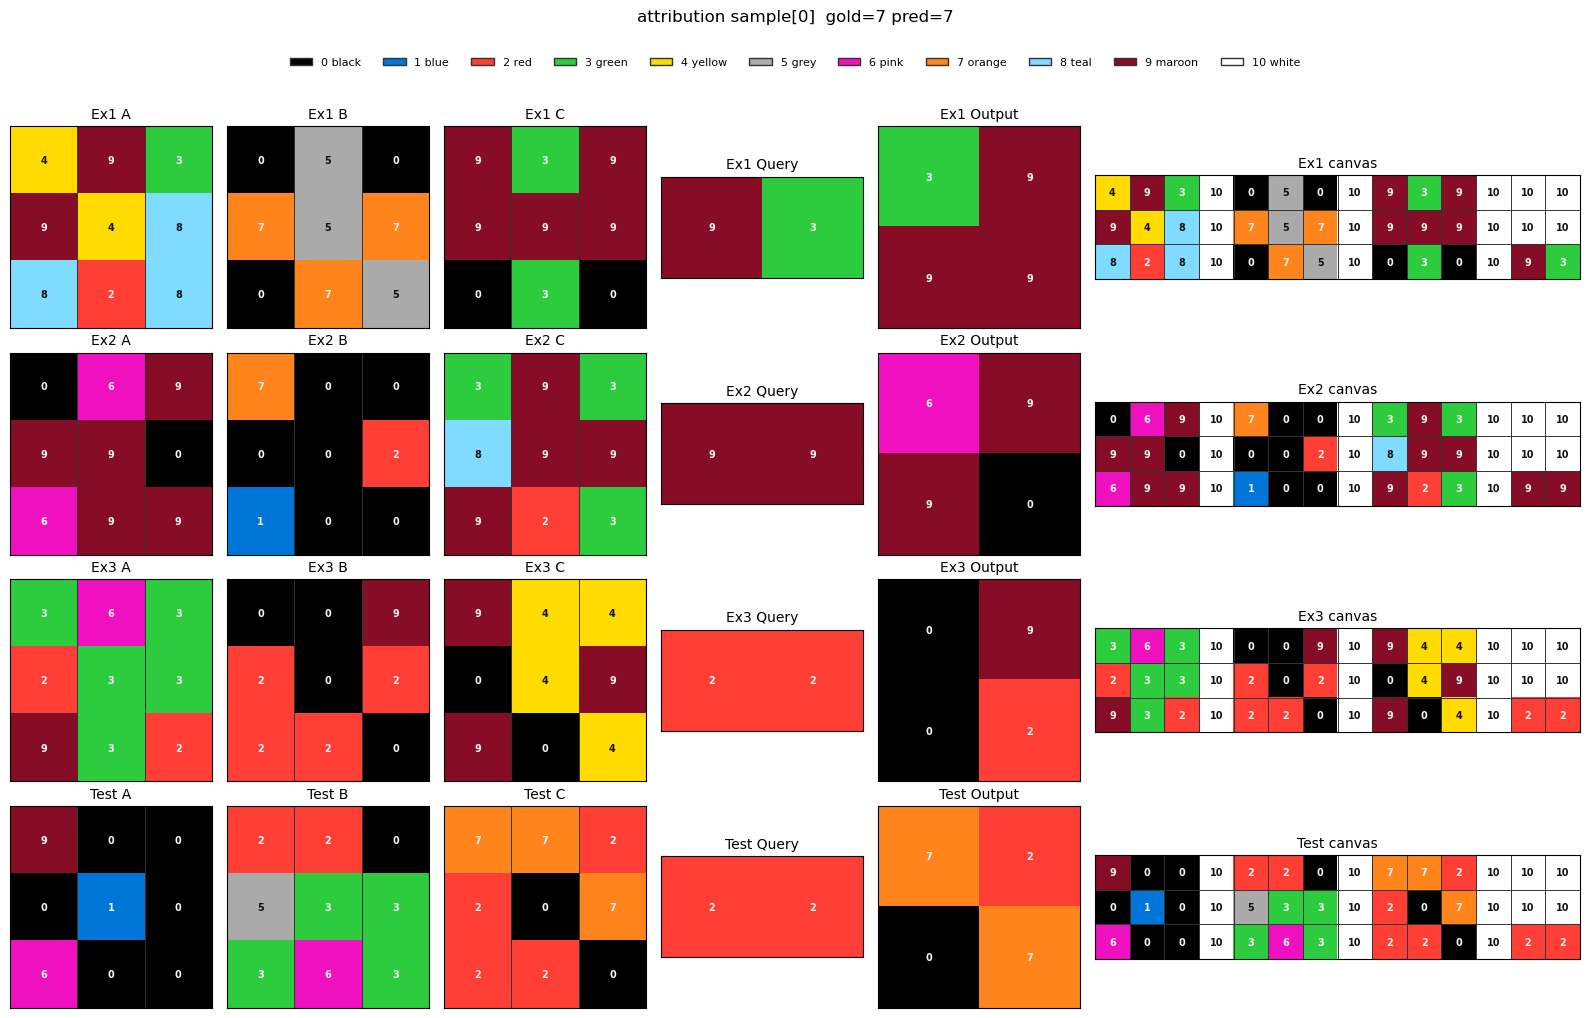

In [60]:
# viz one attribution sample with the scat_targeted grid drawer (fine-tune.ipynb)
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from export_mtm_csv import split_canvas

r = _results[0]
task = r.puzzle
print('sample0 n_tok', r.n_tokens, 'gold', r.answers[0], 'pred', getattr(r, 'responses', [None])[0])
print('cohort', r.index_map[0].get('cohort'))

SHOW_CELL_IDS = True
COLOR_NAMES = ["black","blue","red","green","yellow","grey","pink","orange","teal","maroon","white"]
COLOR_RGB = {
    "black":(0,0,0), "blue":(0.00,0.46,0.85), "red":(1.00,0.25,0.21), "green":(0.18,0.80,0.25),
    "yellow":(1.00,0.86,0.00), "grey":(0.67,0.67,0.67), "pink":(0.94,0.07,0.75),
    "orange":(1.00,0.52,0.11), "teal":(0.50,0.86,1.00), "maroon":(0.53,0.05,0.15), "white":(1,1,1),
}
CMAP = ListedColormap([COLOR_RGB[n] for n in COLOR_NAMES])
NORM = BoundaryNorm(np.arange(-0.5, 11.5, 1.0), CMAP.N)

def draw_grid(ax, grid, title):
    mat = np.array(grid, dtype=int)
    ax.imshow(mat, cmap=CMAP, norm=NORM, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(mat.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(mat.shape[0] + 1) - 0.5, minor=True)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.grid(which="minor", color="#333", linewidth=0.7)
    ax.set_aspect("equal")
    if SHOW_CELL_IDS:
        for rr, cc in np.ndindex(mat.shape):
            v = int(mat[rr, cc])
            ax.text(cc, rr, str(v), ha="center", va="center", fontsize=7, fontweight="bold",
                    color="#111" if v in (4, 5, 8, 10) else "#f5f5f5")

rows = [(f"Ex{i}", ex["input"], ex.get("output")) for i, ex in enumerate(task["train"], 1)]
rows.append(("Test", task["test"][0]["input"], task["test"][0].get("output")))
fig, axes = plt.subplots(len(rows), 6, figsize=(16, 2.4 * len(rows)), gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 2.4]})
if len(rows) == 1:
    axes = np.array([axes])
for irow, (lab, inp, out) in enumerate(rows):
    cands, query = split_canvas(inp)
    draw_grid(axes[irow][0], cands[0], f"{lab} A")
    draw_grid(axes[irow][1], cands[1], f"{lab} B")
    draw_grid(axes[irow][2], cands[2], f"{lab} C")
    draw_grid(axes[irow][3], query, f"{lab} Query")
    if out is None:
        axes[irow][4].axis("off")
        axes[irow][4].set_title(f"{lab} Output")
    else:
        draw_grid(axes[irow][4], out, f"{lab} Output")
    draw_grid(axes[irow][5], inp, f"{lab} canvas")
handles = [Patch(facecolor=COLOR_RGB[n], edgecolor="#333", label=f"{i} {n}") for i, n in enumerate(COLOR_NAMES)]
fig.legend(handles=handles, loc="upper center", ncol=11, frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle(f"attribution sample[0]  gold={r.answers[0]} pred={getattr(r, 'responses', ['?'])[0]}", y=1.06)
fig.tight_layout()
plt.show()

In [ ]:
colored_tokens_multi(*show_attn(random.choice(_results), selected_model, 51, 10, downstreams=tnode.data.nodes, start=_results[0].index_map[0]['start']))#, start=100))

In [ ]:
for cluster_id, heads in d.groups.items():
    for l, h in heads:
        if cluster_id == 1: t, attn_pattern = 'attn_v', 'A-->A-'
        elif cluster_id == 2: t, attn_pattern = 'attn_q', 'A-->QK_C'
        elif cluster_id == 3: t, attn_pattern = 'attn_q', 'A-->V'
        elif cluster_id == 4: t, attn_pattern = 'attn_v', 'A-->X'
        elif cluster_id == 5: t, attn_pattern = 'attn_v', 'A-->QV'
        else: continue
        n = Node(l, h, t, attn_pattern=attn_pattern)
        add_edges(graph, n, d.nodes, d.attr)

In [ ]:
nodes = [Node(l, h, 'attn_v', attn_pattern='A-->V') for l, h in [(50, 60)]]
for n in nodes: add_edges(graph, n, tnode.data.nodes, tnode.data.attr)
tnode = add_tnode(_results, selected_model, nodes, parent=tnode); print_tree(root)

In [ ]:
tnode.data.top_heads

In [ ]:
d = tnode.data
d.groups, d.metrics, _, _ = cluster_heads(d.attn_attrs_ds, threshold=0.5, strengths=d.top_heads, model_config=selected_model.config,
    figsize=(12, 3), width_ratios=(4, 1), bar_height=0.5, leaf_font_size=9)

In [ ]:
attn_patterns = ['A-->V', 'A-->A-', 'V->VK_C', 'V->VK_I', 'A-->QK_C', 'A-->QK_I']
df = pd.DataFrame([(l, h, round(score, 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=False).item(), 4), 
    round(mr(eval_head_lens)(_results, selected_model, l, h, strict=True).item(), 4), 
    round(ap_scores[attn_patterns[0]].mean().item(), 4),
    round(ap_scores[attn_patterns[1]].mean().item(), 4),
    round(ap_scores[attn_patterns[2]].mean().item(), 4),
    round(ap_scores[attn_patterns[3]].mean().item(), 4),
    round(ap_scores[attn_patterns[4]].mean().item(), 4),
    round(ap_scores[attn_patterns[5]].mean().item(), 4))
    for (l, h), score in d.top_heads.items() if (ap_scores := mr(get_head_matching_scores)(_results, attn_patterns, selected_model, l, h))],
    columns=['layer', 'head', 'score', 'acc', 'acc0'] + attn_patterns)
print(df.to_csv(sep='\t', index=True))
# _ = plt.figure(figsize=(8, 2)); _ = sns.heatmap(np.array(attr[60:, :, 0].cpu()), cbar=True)

In [ ]:
from vis import merge_gqa_groups, visualize_graph
for upstream, downstream in g.edges:
    if downstream == lmhead: g.edges[(upstream, downstream)] /= 10.
try:
    vg = merge_gqa_groups(g, selected_model.config)
    visualize_graph(vg, selected_model.config)
finally:
    for upstream, downstream in g.edges:
        if downstream == lmhead: g.edges[(upstream, downstream)] *= 10.

In [ ]:
candidates = join_lists([r.answers for r in results], dedup=True)  # ['K', 'B', 'G', 'R', 'Y']
logits_mask = (torch.ones(model.config.vocab_size) * (-1e4)).to(model.device, dtype=torch.float16)
logits_mask[tokenizer.encode(' ' + ' '.join(candidates))] = 0
mask = torch.eye(model.config.num_attention_heads).to(model.device, dtype=torch.float16) # n*n
pos_ids = torch.LongTensor(r.answer_indices) - 1

In [44]:
for r in _results:
    m = r.index_map[0]
    fin = int(m['Final'])
    toks = model.to_str_tokens(r.prompt, prepend_bos=False)
    print(
        f"i={r.index} n_tokens={r.n_tokens} Final={fin} "
        f"token={toks[fin]!r} prev={toks[fin-3:fin]!r} "
        f"Copy={m.get('Copy')} QLast={m.get('QLast')} "
        f"answer_idx={r.answer_indices[0]}"
    )
print('rule: Final = seq_len - 1 = last prompt token (the position that writes the first answer digit)')

i=0 n_tokens=557 Final=556 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=524 QLast=544 answer_idx=557
i=1 n_tokens=569 Final=568 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=536 QLast=556 answer_idx=569
i=2 n_tokens=557 Final=556 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=507 QLast=544 answer_idx=557
i=3 n_tokens=565 Final=564 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=536 QLast=552 answer_idx=565
i=4 n_tokens=565 Final=564 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=513 QLast=552 answer_idx=565
i=5 n_tokens=553 Final=552 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=524 QLast=540 answer_idx=553
i=6 n_tokens=553 Final=552 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=495 QLast=540 answer_idx=553
i=7 n_tokens=553 Final=552 token='\n\n' prev=['<think>', '\n\n', '</think>'] Copy=474 QLast=540 answer_idx=553
rule: Final = seq_len - 1 = last prompt token (the position that writes the first answer digit)


In [45]:
print('=== first generated token vs Copy vs gold[0][0] ===')
for r in _results:
    m = r.index_map[0]
    toks = model.to_str_tokens(r.prompt, prepend_bos=False)
    copy = int(m['Copy'])
    gold = r.puzzle['test'][0]['output']
    ans_text = r.answers[0]
    ans_ids = tokenizer.encode(r.answers[0] if False else str(gold[0][0]), add_special_tokens=False)
    # actual first-token id used in Result
    first_id = r.labels[0]
    pred = r.responses[0] if r.responses else None
    print(
        f"i={r.index} gold={gold} answer_field={r.answers!r} first_id={first_id} decode={tokenizer.decode([first_id])!r} "
        f"pred={pred!r} Copy@{copy}={toks[copy]!r} winner={m.get('winner')} origin={m.get('value_cell')}"
    )

=== first generated token vs Copy vs gold[0][0] ===
i=0 gold=[[7, 2], [0, 7]] answer_field=['7'] first_id=22 decode='7' pred='7' Copy@524='7' winner=C origin=[0, 1]
i=1 gold=[[6, 0], [0, 0], [2, 0]] answer_field=['6'] first_id=21 decode='6' pred='6' Copy@536='6' winner=C origin=[0, 1]
i=2 gold=[[2, 0], [7, 1]] answer_field=['2'] first_id=17 decode='2' pred='2' Copy@507='2' winner=B origin=[1, 0]
i=3 gold=[[5, 3], [2, 2]] answer_field=['5'] first_id=20 decode='5' pred='5' Copy@536='5' winner=C origin=[1, 1]
i=4 gold=[[0, 8], [0, 0]] answer_field=['0'] first_id=15 decode='0' pred='0' Copy@513='0' winner=B origin=[1, 0]
i=5 gold=[[4], [1]] answer_field=['4'] first_id=19 decode='4' pred='4' Copy@524='4' winner=C origin=[1, 1]
i=6 gold=[[0], [2]] answer_field=['0'] first_id=15 decode='0' pred='0' Copy@495='0' winner=B origin=[0, 0]
i=7 gold=[[9, 9]] answer_field=['9'] first_id=24 decode='9' pred='9' Copy@474='9' winner=A origin=[0, 0]


In [46]:
import math
attr = tnode.data.attr
print('attr', tuple(attr.shape), 'dtype', attr.dtype)
a = attr.detach().float().abs().sum(-1)  # [L, H+1]
print('nan', bool(torch.isnan(attr).any()), 'inf', bool(torch.isinf(attr).any()))
print('per-layer attn max', [round(float(a[l, :64].max()), 3) if a[l, :64].numel() else None for l in range(0, 64, 4)])
# top 20 including mlp
flat = a.cpu()
vals, idx = torch.topk(flat.reshape(-1), 20)
H1 = flat.shape[1]
print('top20 (layer, head_or_mlp, score):')
for v, i in zip(vals.tolist(), idx.tolist()):
    l, h = divmod(i, H1)
    kind = 'mlp' if h >= 64 else 'attn'
    print(f'  L{l} h{h} {kind} {v:.4g}')
print('current top_heads', dict(tnode.data.top_heads))
print('hung layers this node', [n.layer for n in tnode.data.nodes])
# how many layers 20-46 have any attn mass
band = a[20:47, :64]
print('L20-46 attn max', float(band.max()), 'sum', float(band.sum()), 'nan', bool(torch.isnan(band).any()))
print('L0-5 attn max', [round(float(a[l, :64].max()), 4) for l in range(6)])
print('L40-51 attn max', [round(float(a[l, :64].max()), 4) for l in range(40, 52)])

attr (51, 65, 6) dtype torch.float16
nan True inf False


IndexError: index 52 is out of bounds for dimension 0 with size 51

In [47]:
attr = tnode.data.attr.detach().float()
print('attr', tuple(attr.shape), 'nan', int(torch.isnan(attr).sum()), '/', attr.numel())
a = attr.abs().sum(-1)  # [51, 65]
print('nan layers (attn any)', [l for l in range(a.shape[0]) if bool(torch.isnan(a[l, :64]).any())])
print('nan layers (mlp)', [l for l in range(a.shape[0]) if bool(torch.isnan(a[l, 64]))])
finite = torch.nan_to_num(a, nan=-1.0)
vals, idx = torch.topk(finite.reshape(-1), 25)
H1 = finite.shape[1]
print('top25 after nan->-1:')
for v, i in zip(vals.tolist(), idx.tolist()):
    l, h = divmod(int(i), H1)
    print(f'  L{l} h{h} {"mlp" if h>=64 else "attn"} {v:.4g}')
print('L20-46 attn finite max', float(torch.nan_to_num(a[20:47, :64], nan=0).max()))
print('L0-10 attn finite max', [round(float(torch.nan_to_num(a[l, :64], nan=0).max()), 3) for l in range(11)])
print('L40-50 attn finite max', [round(float(torch.nan_to_num(a[l, :64], nan=0).max()), 3) for l in range(40, 51)])
print('hung', [(n.layer, n.head, n.type, n.attn_pattern) for n in tnode.data.nodes])
print('raw top_heads', tnode.data.top_heads)

attr (51, 65, 6) nan 16575 / 19890
nan layers (attn any) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
nan layers (mlp) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
top25 after nan->-1:
  L0 h24 attn -1
  L0 h18 attn -1
  L0 h16 attn -1
  L0 h17 attn -1
  L0 h21 attn -1
  L0 h20 attn -1
  L0 h22 attn -1
  L0 h23 attn -1
  L0 h19 attn -1
  L0 h10 attn -1
  L0 h8 attn -1
  L0 h9 attn -1
  L0 h13 attn -1
  L0 h12 attn -1
  L0 h14 attn -1
  L0 h15 attn -1
  L0 h7 attn -1
  L0 h6 attn -1
  L0 h4 attn -1
  L0 h5 attn -1
  L0 h1 attn -1
  L0 h0 attn -1
  L0 h2 attn -1
  L0 h3 attn -1
  L0 h11 attn -1
L20-46 attn finite max 0.0
L0-10 attn finite max [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 